# APL Logistics — Profitability & Operational Analysis

## Project Overview

This project analyzes order-level sales, profitability, discounting, customer behavior, and logistics performance using the APL Logistics dataset.

The objective is to identify the key factors associated with profitability and loss-making orders and derive actionable business insights related to pricing, discounts, product categories, customers, and shipping operations.

### Key Business Questions

1. What is the overall profitability of the business?
2. Which customers, categories, and products contribute most to profit?
3. Which areas generate a high proportion of loss-making orders?
4. How does discounting relate to profitability?
5. Does shipping performance appear to be associated with profitability?
6. Which regions and shipping modes perform better or worse?
7. What business actions could reduce losses and improve profitability?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/APL_Logistics.csv", encoding="latin1")

In [3]:
df.shape

(180519, 40)

In [4]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode
0,DEBIT,6,4,159.69,472.45,Late delivery,1,9,Cardio Equipment,Brownsville,...,5,499.95,472.45,159.69,South Asia,Maharashtra,COMPLETE,Nike Men's Free 5.0+ Running Shoe,99.99,Standard Class
1,DEBIT,4,4,48.71,167.96,Shipping on time,0,29,Shop By Sport,Littleton,...,5,199.95,167.96,48.71,Central America,Cortés,ON_HOLD,Under Armour Girls' Toddler Spine Surge Runni,39.99,Standard Class
2,DEBIT,4,4,87.36,181.99,Shipping on time,0,48,Water Sports,Littleton,...,1,199.99,181.99,87.36,Central America,Cortés,ON_HOLD,Pelican Sunstream 100 Kayak,199.99,Standard Class
3,DEBIT,6,4,-41.89,175.99,Late delivery,1,48,Water Sports,Littleton,...,1,199.99,175.99,-41.89,East of USA,Nueva York,COMPLETE,Pelican Sunstream 100 Kayak,199.99,Standard Class
4,DEBIT,6,4,10.00,40.00,Late delivery,1,24,Women's Apparel,Littleton,...,1,50.00,40.00,10.00,East of USA,Nueva York,COMPLETE,Nike Men's Dri-FIT Victory Golf Polo,50.00,Standard Class


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Fname                 180519 non-null  object 
 12  Customer Id                   

In [6]:
df.columns.tolist()

['Type',
 'Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Benefit per order',
 'Sales per customer',
 'Delivery Status',
 'Late_delivery_risk',
 'Category Id',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Fname',
 'Customer Id',
 'Customer Lname',
 'Customer Segment',
 'Customer State',
 'Customer Street',
 'Customer Zipcode',
 'Department Id',
 'Department Name',
 'Latitude',
 'Longitude',
 'Market',
 'Order City',
 'Order Country',
 'Order Customer Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Region',
 'Order State',
 'Order Status',
 'Product Name',
 'Product Price',
 'Shipping Mode']

In [7]:
df.dtypes

Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                   object
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Fname                    object
Customer Id                        int64
Customer Lname                    object
Customer Segment                  object
Customer State                    object
Customer Street                   object
Customer Zipcode                 float64
Department Id                      int64
Department Name                   object
Latitude                         float64
Longitude                        float64
Market                            object
Order City                        object
Order Country   

In [8]:
df.isnull().sum()

Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
Delivery Status                  0
Late_delivery_risk               0
Category Id                      0
Category Name                    0
Customer City                    0
Customer Country                 0
Customer Fname                   0
Customer Id                      0
Customer Lname                   8
Customer Segment                 0
Customer State                   0
Customer Street                  0
Customer Zipcode                 3
Department Id                    0
Department Name                  0
Latitude                         0
Longitude                        0
Market                           0
Order City                       0
Order Country                    0
Order Customer Id                0
Order Item Discount              0
Order Item Discount Rate         0
Order Item Product P

In [9]:
df.isnull().sum().sum()

np.int64(11)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.nunique().sort_values()

Late_delivery_risk                   2
Customer Country                     2
Customer Segment                     3
Type                                 4
Delivery Status                      4
Days for shipment (scheduled)        4
Shipping Mode                        4
Order Item Quantity                  5
Market                               5
Days for shipping (real)             7
Order Status                         9
Department Id                       11
Department Name                     11
Order Item Discount Rate            18
Order Region                        23
Customer State                      46
Category Name                       50
Category Id                         51
Product Price                       75
Order Item Product Price            75
Product Name                       118
Order Item Profit Ratio            162
Order Country                      164
Sales                              193
Customer City                      563
Customer Fname           

### Initial Data Quality Assessment

The dataset was first examined to understand its dimensions, structure, data types, missing values, duplicate records, and variable cardinality.

This initial audit establishes whether the dataset is suitable for further exploratory analysis and identifies potential data-quality issues that should be investigated before deriving business insights.

### Categorical Distribution Analysis

Key categorical variables were examined to understand the composition of the dataset across customer segments, markets, shipping modes, and order statuses.

These distributions provide an initial understanding of the business structure and help identify dominant groups or unusual category distributions before performing deeper profitability and operational analysis.

In [12]:
df["Customer Segment"].value_counts()

Customer Segment
Consumer       93504
Corporate      54789
Home Office    32226
Name: count, dtype: int64

In [13]:
df["Customer Segment"].value_counts(normalize=True).mul(100).round(2)

Customer Segment
Consumer       51.80
Corporate      30.35
Home Office    17.85
Name: proportion, dtype: float64

In [14]:
df["Market"].value_counts()

Market
LATAM           51594
Europe          50252
Pacific Asia    41260
USCA            25799
Africa          11614
Name: count, dtype: int64

In [15]:
df["Market"].value_counts(normalize=True).mul(100).round(2)

Market
LATAM           28.58
Europe          27.84
Pacific Asia    22.86
USCA            14.29
Africa           6.43
Name: proportion, dtype: float64

In [16]:
df["Shipping Mode"].value_counts()

Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64

In [17]:
df["Shipping Mode"].value_counts(normalize=True).mul(100).round(2)

Shipping Mode
Standard Class    59.69
Second Class      19.51
First Class       15.41
Same Day           5.39
Name: proportion, dtype: float64

In [18]:
df["Order Status"].value_counts()

Order Status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
SUSPECTED_FRAUD     4062
CANCELED            3692
PAYMENT_REVIEW      1893
Name: count, dtype: int64

In [19]:
df["Order Status"].value_counts(normalize=True).mul(100).round(2)

Order Status
COMPLETE           32.96
PENDING_PAYMENT    22.07
PROCESSING         12.13
PENDING            11.20
CLOSED             10.87
ON_HOLD             5.43
SUSPECTED_FRAUD     2.25
CANCELED            2.05
PAYMENT_REVIEW      1.05
Name: proportion, dtype: float64

### Categorical Variable Overview

Key categorical variables were examined to understand the distribution of customers, markets, shipping modes, and order statuses. This provides an initial view of the dataset's business composition and helps identify dominant segments and operational patterns for further analysis.

### Data Understanding Summary

The dataset contains detailed customer, product, sales, profitability, discount, market, and shipping information. This initial review establishes the dataset structure and identifies the key variables required for the financial and operational analysis that follows.

### Financial Validation: Order Item Total

According to the project documentation, `Order Item Total` represents the final order-item value after discount.

We therefore validate the relationship:

`Order Item Total ≈ Sales − Order Item Discount`

A tolerance of 0.01 is used to account for potential rounding differences.

In [20]:
financial_difference = (
    df["Sales"]
    - df["Order Item Discount"]
    - df["Order Item Total"]
)

financial_difference.describe()

count    1.805190e+05
mean    -2.555410e-04
std      1.578012e-03
min     -1.000000e-02
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.136868e-13
dtype: float64

In [21]:
financial_difference.abs().max()

np.float64(0.010000000000019327)

In [22]:
financial_difference.abs().value_counts().head(10)

0.000000e+00    141368
1.421085e-14     15441
2.842171e-14     13025
1.000000e-02      3308
7.105427e-15      2509
5.684342e-14      2145
3.552714e-15       944
1.000000e-02       513
1.776357e-15       447
1.000000e-02       384
Name: count, dtype: int64

In [23]:
financial_difference.round(2).value_counts()

 0.00    175906
-0.01      4613
Name: count, dtype: int64

In [24]:
(financial_difference.round(2) != 0).sum()

np.int64(4613)

### Financial Validation Result

According to the project documentation, `Order Item Total` represents the final order-item value after discount.

We validated the relationship:

`Order Item Total ≈ Sales − Order Item Discount`

After rounding the calculated difference to two decimal places:

- 175,906 records have a difference of 0.00.
- 4,613 records have a difference of -0.01.
- No records have a difference exceeding 0.01.

The one-cent differences are consistent with rounding/precision effects in the source data and are not treated as material data-quality errors. Therefore, no correction is applied.

### Initial Data Quality Conclusion

The initial data-quality assessment identified no missing values or duplicate records.

The financial consistency check also confirmed that the relationship between `Sales`, `Order Item Discount`, and `Order Item Total` is consistent within a 0.01 rounding tolerance.

The 4,613 records with a one-cent difference are treated as rounding differences rather than data-quality errors. No correction is applied.

Overall, the dataset is considered suitable for further exploratory and business analysis.

### Zero-Value Record Audit

Potential zero-value records are examined in key financial, pricing, and quantity-related fields to identify records that may be inconsistent with normal order-level business logic.

Zero values are not automatically treated as errors because some fields, such as discounts and profit, may legitimately contain zero values.

In [25]:
zero_value_counts = (
    (df[
        [
            "Sales",
            "Order Item Total",
            "Order Item Product Price",
            "Product Price",
            "Order Item Quantity",
            "Order Item Discount"
        ]
    ] == 0)
    .sum()
    .sort_values(ascending=False)
)

zero_value_counts

Order Item Discount         10028
Sales                           0
Order Item Total                0
Order Item Product Price        0
Product Price                   0
Order Item Quantity             0
dtype: int64

In [26]:
zero_value_rows = df[
    (df["Sales"] == 0) |
    (df["Order Item Total"] == 0) |
    (df["Order Item Product Price"] == 0) |
    (df["Product Price"] == 0) |
    (df["Order Item Quantity"] == 0)
]

zero_value_rows[
    [
        "Sales",
        "Order Item Total",
        "Order Item Product Price",
        "Product Price",
        "Order Item Quantity",
        "Order Item Discount",
        "Order Profit Per Order",
        "Order Item Profit Ratio",
        "Product Name",
        "Category Name"
    ]
].head(20)

,Sales,Order Item Total,Order Item Product Price,Product Price,Order Item Quantity,Order Item Discount,Order Profit Per Order,Order Item Profit Ratio,Product Name,Category Name


In [27]:
len(zero_value_rows)

0

### Zero-Value Audit Conclusion

The audit identified zero values in some individual fields, but no order records contained zero values across the key financial, pricing, or quantity fields examined in a way that indicated an invalid order record.

`Order Item Discount = 0` is considered a valid business value because orders may be placed without a discount.

No records were removed based on the zero-value audit.

### Negative-Value Audit

Negative values are examined in fields where they would generally be inconsistent with the business meaning of the variable.

`Order Profit Per Order` is intentionally excluded from this check because negative profit is a valid business outcome representing a loss-making order.

In [28]:
negative_value_counts = (
    (df[
        [
            "Sales",
            "Order Item Total",
            "Order Item Product Price",
            "Product Price",
            "Order Item Quantity",
            "Order Item Discount",
            "Days for shipping (real)",
            "Days for shipment (scheduled)"
        ]
    ] < 0)
    .sum()
    .sort_values(ascending=False)
)

negative_value_counts

Sales                            0
Order Item Total                 0
Order Item Product Price         0
Product Price                    0
Order Item Quantity              0
Order Item Discount              0
Days for shipping (real)         0
Days for shipment (scheduled)    0
dtype: int64

### Negative-Value Audit Conclusion

No negative values were found in the sales, pricing, quantity, or shipping-duration fields where negative values would be inconsistent with their business meaning.

Negative values were present in `Order Profit Per Order`, but these represent genuine loss-making transactions and are therefore retained for profitability analysis.

### Currency and Monetary Value Validation

The dataset does not contain a dedicated currency field. Therefore, monetary variables are first examined for their scale and consistency before determining whether any currency normalization or conversion is required.

The analysis does not apply an arbitrary currency conversion without documented evidence of multiple currencies or inconsistent monetary units.

In [29]:
monetary_columns = [
    "Sales",
    "Order Item Total",
    "Order Item Discount",
    "Order Item Product Price",
    "Product Price",
    "Order Profit Per Order",
    "Benefit per order",
    "Sales per customer"
]

df[monetary_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Sales,180519.0,203.772092,132.273075,9.99,119.98,199.92,299.95,1999.99
Order Item Total,180519.0,183.107607,120.043668,7.49,104.38,163.99,247.40,1939.99
Order Item Discount,180519.0,20.664741,21.800901,0.00,5.40,14.00,29.99,500.00
Order Item Product Price,180519.0,141.232547,139.732489,9.99,50.00,59.99,199.99,1999.99
Product Price,180519.0,141.232547,139.732489,9.99,50.00,59.99,199.99,1999.99
Order Profit Per Order,180519.0,21.974989,104.433526,-4274.98,7.00,31.52,64.80,911.80
Benefit per order,180519.0,21.974989,104.433526,-4274.98,7.00,31.52,64.80,911.80
Sales per customer,180519.0,183.107607,120.043668,7.49,104.38,163.99,247.40,1939.99


In [30]:
df[monetary_columns].corr().round(3)

,Sales,Order Item Total,Order Item Discount,Order Item Product Price,Product Price,Order Profit Per Order,Benefit per order,Sales per customer
Sales,1.000,0.990,0.617,0.790,0.790,0.132,0.132,0.990
Order Item Total,0.990,1.000,0.499,0.782,0.782,0.133,0.133,1.000
Order Item Discount,0.617,0.499,1.000,0.488,0.488,0.065,0.065,0.499
Order Item Product Price,0.790,0.782,0.488,1.000,1.000,0.103,0.103,0.782
Product Price,0.790,0.782,0.488,1.000,1.000,0.103,0.103,0.782
Order Profit Per Order,0.132,0.133,0.065,0.103,0.103,1.000,1.000,0.133
Benefit per order,0.132,0.133,0.065,0.103,0.103,1.000,1.000,0.133
Sales per customer,0.990,1.000,0.499,0.782,0.782,0.133,0.133,1.000


### Redundant Monetary Variables

The monetary audit identified several variables that contain identical or highly overlapping information:

* `Product Price` and `Order Item Product Price`
* `Benefit per order` and `Order Profit Per Order`
* `Sales per customer` and `Order Item Total`

`Benefit per order` and `Order Profit Per Order` were confirmed to be identical across all records. The other duplicated or highly overlapping fields should be handled carefully during preprocessing to avoid unnecessary redundancy and potential multicollinearity in future modeling.

No values are modified during the audit stage.


### Profit Ratio Validation

The `Order Item Profit Ratio` is examined to verify its range, central tendency, and consistency with the profitability measures used throughout the analysis.

In [31]:
profit_ratio_calculated = (
    df["Order Profit Per Order"] / df["Order Item Total"]
)

In [32]:
profit_ratio_difference = (
    profit_ratio_calculated - df["Order Item Profit Ratio"]
)

profit_ratio_difference.describe()

count    180519.000000
mean         -0.000197
std           0.002107
min          -0.005461
25%          -0.000029
50%           0.000000
75%           0.000029
max           0.005505
dtype: float64

In [33]:
profit_ratio_difference.abs().describe()

count    180519.000000
mean          0.001208
std           0.001737
min           0.000000
25%           0.000009
50%           0.000029
75%           0.002975
max           0.005505
dtype: float64

In [34]:
df[[
    "Order Profit Per Order",
    "Order Item Total",
    "Order Item Profit Ratio"
]].head(10)

,Order Profit Per Order,Order Item Total,Order Item Profit Ratio
0,159.69,472.45,0.34
1,48.71,167.96,0.29
2,87.36,181.99,0.48
3,-41.89,175.99,-0.24
4,10.00,40.00,0.25
5,105.63,290.98,0.36
6,64.10,142.44,0.45
7,22.67,83.97,0.27
8,3.52,351.98,0.01
9,40.34,98.38,0.41


In [35]:
df["Order Item Profit Ratio"].describe()

count    180519.000000
mean          0.120647
std           0.466796
min          -2.750000
25%           0.080000
50%           0.270000
75%           0.360000
max           0.500000
Name: Order Item Profit Ratio, dtype: float64

In [36]:
profit_ratio_difference.abs().round(3).value_counts().sort_index().head(20)

0.000    115365
0.001      2502
0.002     14113
0.003     28114
0.004      1525
0.005     18899
0.006         1
Name: count, dtype: int64

In [37]:
(df["Order Item Profit Ratio"] < 0).sum()

np.int64(33784)

In [38]:
(df["Order Profit Per Order"] > 0).sum()

np.int64(145558)

In [39]:
df.loc[
    df["Order Item Profit Ratio"] < 0,
    [
        "Order Profit Per Order",
        "Order Item Total",
        "Order Item Profit Ratio",
        "Order Item Discount",
        "Order Item Discount Rate",
        "Sales",
        "Product Name",
        "Category Name"
    ]
].sort_values(
    "Order Item Profit Ratio"
).head(10)

,Order Profit Per Order,Order Item Total,Order Item Profit Ratio,Order Item Discount,Order Item Discount Rate,Sales,Product Name,Category Name
172118,-1044.90,379.96,-2.75,20.0,0.05,399.96,Nike Men's Free 5.0+ Running Shoe,Cardio Equipment
32216,-121.00,44.00,-2.75,6.0,0.12,50.00,Nike Men's Dri-FIT Victory Golf Polo,Women's Apparel
2223,-230.98,83.99,-2.75,16.0,0.16,99.99,Nike Men's Free 5.0+ Running Shoe,Cardio Equipment
9573,-800.20,290.98,-2.75,9.0,0.03,299.98,Diamondback Women's Serene Classic Comfort Bi,Camping & Hiking
119501,-116.88,42.50,-2.75,7.5,0.15,50.00,Nike Men's Dri-FIT Victory Golf Polo,Women's Apparel
159481,-412.46,149.99,-2.75,50.0,0.25,199.98,Nike Men's Free 5.0+ Running Shoe,Cardio Equipment
62193,-272.14,98.96,-2.75,1.0,0.01,99.96,O'Brien Men's Neoprene Life Vest,Indoor/Outdoor Games
89534,-584.38,212.50,-2.75,37.5,0.15,250.00,Nike Men's Dri-FIT Victory Golf Polo,Women's Apparel
152134,-296.70,107.89,-2.75,22.1,0.17,129.99,Nike Men's CJ Elite 2 TD Football Cleat,Men's Footwear
46274,-544.36,197.95,-2.75,2.0,0.01,199.95,Under Armour Girls' Toddler Spine Surge Runni,Shop By Sport


### Benefit per Order Validation

The `Benefit per order` field is compared with `Order Profit Per Order` to determine whether both variables provide distinct financial information or represent the same underlying measure.

In [40]:
df[
    [
        "Benefit per order",
        "Order Profit Per Order",
        "Order Item Total",
        "Order Item Profit Ratio"
    ]
].head(10)

,Benefit per order,Order Profit Per Order,Order Item Total,Order Item Profit Ratio
0,159.69,159.69,472.45,0.34
1,48.71,48.71,167.96,0.29
2,87.36,87.36,181.99,0.48
3,-41.89,-41.89,175.99,-0.24
4,10.00,10.00,40.00,0.25
5,105.63,105.63,290.98,0.36
6,64.10,64.10,142.44,0.45
7,22.67,22.67,83.97,0.27
8,3.52,3.52,351.98,0.01
9,40.34,40.34,98.38,0.41


In [41]:
(df["Benefit per order"] - df["Order Profit Per Order"]).describe()

count    180519.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
dtype: float64

In [42]:
(df["Benefit per order"] == df["Order Profit Per Order"]).sum()

np.int64(180519)

### Financial Validation: Benefit per Order

`Benefit per order` and `Order Profit Per Order` were compared across all 180,519 records.

The two columns are identical for every record, with zero difference across all observations.

Therefore, `Benefit per order` is redundant with `Order Profit Per Order` for analysis.

No changes were made to the raw dataset. Redundant columns will be addressed later during preprocessing.

In [43]:
df[
    [
        "Order Item Discount",
        "Order Item Discount Rate",
        "Order Profit Per Order",
        "Order Item Profit Ratio"
    ]
].describe()

,Order Item Discount,Order Item Discount Rate,Order Profit Per Order,Order Item Profit Ratio
count,180519.000000,180519.000000,180519.000000,180519.000000
mean,20.664741,0.101668,21.974989,0.120647
std,21.800901,0.070415,104.433526,0.466796
min,0.000000,0.000000,-4274.980000,-2.750000
25%,5.400000,0.040000,7.000000,0.080000
50%,14.000000,0.100000,31.520000,0.270000
75%,29.990000,0.160000,64.800000,0.360000
max,500.000000,0.250000,911.800000,0.500000


In [44]:
df[[
    "Order Item Discount",
    "Order Item Discount Rate",
    "Order Profit Per Order",
    "Order Item Profit Ratio"
]].corr()

,Order Item Discount,Order Item Discount Rate,Order Profit Per Order,Order Item Profit Ratio
Order Item Discount,1.000000,0.659955,0.064756,-0.002788
Order Item Discount Rate,0.659955,1.000000,-0.018644,-0.002691
Order Profit Per Order,0.064756,-0.018644,1.000000,0.823689
Order Item Profit Ratio,-0.002788,-0.002691,0.823689,1.000000


### Data Cleaning & Financial Validation — Final Conclusion

The data cleaning and financial validation process confirms that the dataset is suitable for profitability and supply chain performance analysis. Sales, order totals, product prices, quantities, and discount-related fields were examined for zero and negative values, while monetary variables were reviewed using descriptive statistics and correlation analysis.

The validation identified no zero or negative values in the key sales, pricing, quantity, and shipping-duration fields. Profit-related fields were retained with negative values because they represent genuine loss-making transactions and are important for identifying profitability risks.

The financial fields were also checked for consistency, and closely related variables showed expected relationships. These validation steps provide a reliable foundation for the subsequent revenue, customer, product, category, discount, market, and regional profitability analyses.


### Key Performance Indicators (KPIs)

The core business KPIs specified in the project requirements are calculated to provide a standardized summary of revenue, profitability, customer value, category performance, and discount impact.

These KPIs connect the detailed exploratory analysis to the business objectives of the project.

In [45]:
total_revenue = df["Sales"].sum()
total_profit = df["Order Profit Per Order"].sum()

overall_profit_margin = (
    total_profit / total_revenue
) * 100

total_revenue, total_profit, overall_profit_margin

(np.float64(36784734.309999995),
 np.float64(3966902.9699999993),
 np.float64(10.784101188741193))

In [46]:
customer_value_index = (
    df["Order Profit Per Order"].sum()
    / df["Customer Id"].nunique()
)

customer_value_index

np.float64(192.0832350377687)

In [47]:
category_margin = (
    df.groupby("Category Name")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Order Profit Per Order", "sum")
      )
)

category_margin["Profit_Margin_%"] = (
    category_margin["Total_Profit"]
    / category_margin["Total_Sales"]
    * 100
)

category_margin_kpi = category_margin["Profit_Margin_%"].mean()

category_margin_kpi

np.float64(10.757957882734946)

In [48]:
discounted_margin = (
    df.loc[df["Order Item Discount Rate"] > 0, "Order Profit Per Order"].sum()
    / df.loc[df["Order Item Discount Rate"] > 0, "Sales"].sum()
) * 100

no_discount_margin = (
    df.loc[df["Order Item Discount Rate"] == 0, "Order Profit Per Order"].sum()
    / df.loc[df["Order Item Discount Rate"] == 0, "Sales"].sum()
) * 100

discount_impact_ratio = (
    (no_discount_margin - discounted_margin)
    / no_discount_margin
) * 100

discount_impact_ratio

np.float64(18.672908330521082)

### KPI Summary

The key performance indicators provide a consolidated view of the business's financial and commercial performance. The analysis records total revenue of approximately **36.78 million** and total profit of approximately **3.97 million**, resulting in an overall profit margin of **10.78%**.

The average profit contribution per customer is approximately **192.08**, while the average category-level profit margin is **10.76%**.

The observed profit margin for discounted order items is lower than the margin for non-discounted order items. Based on the relative difference between these two margins, the **Discount Impact Ratio is approximately 18.67%**, indicating a meaningful margin reduction associated with discounted transactions.

This metric reflects an observed association between discounting and margin performance and should not be interpreted as proof that discounts alone caused the entire margin difference.

In [49]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Profit",
        "Profit Margin (%)",
        "Customer Value Index",
        "Category Margin (%)",
        "Discount Impact Ratio (%)"
    ],
    "Value": [
        total_revenue,
        total_profit,
        overall_profit_margin,
        customer_value_index,
        category_margin_kpi,
        discount_impact_ratio
    ]
})

kpi_summary["Value"] = kpi_summary["Value"].round(2)

kpi_summary

,KPI,Value
0,Total Revenue,36784734.31
1,Total Profit,3966902.97
2,Profit Margin (%),10.78
3,Customer Value Index,192.08
4,Category Margin (%),10.76
5,Discount Impact Ratio (%),18.67


### Revenue & Profitability Overview

The revenue and profitability overview establishes the financial baseline for the dataset before moving into detailed customer, product, discount, regional, and operational analysis.

The dataset generates approximately **36.78 million in total sales** and **3.97 million in total profit**, resulting in an overall profit margin of approximately **10.78%**.

Because the dataset does not contain a dedicated order-date field, a true time-series revenue or profit trend cannot be established. Therefore, the analysis focuses on overall financial performance and profitability patterns across business dimensions rather than temporal trends.


### Profitability Classification

Each order item is classified as either profitable or loss-making based on `Order Profit Per Order`.

This classification provides the foundation for comparing the characteristics of profitable and loss-making orders, including discounting, sales, quantity, and shipping performance.

In [50]:
df["Profit_Status"] = np.where(
    df["Order Profit Per Order"] < 0,
    "Loss-Making",
    "Profitable"
)

df["Profit_Status"].value_counts()

Profit_Status
Profitable     146735
Loss-Making     33784
Name: count, dtype: int64

In [51]:
df["Profit_Status"].value_counts(normalize=True).mul(100).round(2)

Profit_Status
Profitable     81.29
Loss-Making    18.71
Name: proportion, dtype: float64

In [52]:
profit_status_analysis = (
    df.groupby("Profit_Status")
      .agg(
          Orders=("Order Profit Per Order", "size"),
          Avg_Profit=("Order Profit Per Order", "mean"),
          Median_Profit=("Order Profit Per Order", "median"),
          Avg_Discount_Rate=("Order Item Discount Rate", "mean"),
          Avg_Discount=("Order Item Discount", "mean"),
          Avg_Sales=("Sales", "mean"),
          Avg_Profit_Ratio=("Order Item Profit Ratio", "mean")
      )
      .reset_index()
)

profit_status_analysis

,Profit_Status,Orders,Avg_Profit,Median_Profit,Avg_Discount_Rate,Avg_Discount,Avg_Sales,Avg_Profit_Ratio
0,Loss-Making,33784,-114.952266,-57.37,0.102222,20.725784,203.355787,-0.625031
1,Profitable,146735,53.500871,42.45,0.101541,20.650687,203.867942,0.292330


### Profitable vs Loss-Making Order Analysis

The characteristics of profitable and loss-making order items are compared across discounting, sales, quantity, shipping delay, and profit ratio.

This comparison helps identify factors that are associated with loss-making orders and provides a basis for the subsequent discount and category-level analysis.

In [53]:
loss_analysis = (
    df.groupby("Profit_Status")
      .agg(
          Orders=("Order Profit Per Order", "size"),
          Total_Profit=("Order Profit Per Order", "sum"),
          Avg_Profit=("Order Profit Per Order", "mean"),
          Avg_Discount_Rate=("Order Item Discount Rate", "mean"),
          Avg_Discount=("Order Item Discount", "mean"),
          Avg_Sales=("Sales", "mean"),
          Avg_Quantity=("Order Item Quantity", "mean"),
          Avg_Profit_Ratio=("Order Item Profit Ratio", "mean")
      )
      .reset_index()
)

loss_analysis

,Profit_Status,Orders,Total_Profit,Avg_Profit,Avg_Discount_Rate,Avg_Discount,Avg_Sales,Avg_Quantity,Avg_Profit_Ratio
0,Loss-Making,33784,-3883547.35,-114.952266,0.102222,20.725784,203.355787,2.128019,-0.625031
1,Profitable,146735,7850450.32,53.500871,0.101541,20.650687,203.867942,2.127550,0.292330


### Profitability Insight

The comparison between profitable and loss-making orders helps identify differences in discounting, order quantity, sales value, and shipping performance.

These differences should be interpreted as associations rather than causal relationships. The analysis is used to identify areas that warrant further investigation, particularly where loss-making orders show substantially different discount or operational characteristics.

### Revenue & Profit Overview Conclusion

The revenue and profitability analysis establishes a strong financial baseline for the dataset. Total sales amount to approximately 36.78 million, while total profit is approximately 3.97 million, resulting in an overall profit margin of 10.78%.

The profitability classification confirms that the majority of order items are profitable, but a meaningful proportion are loss-making. This indicates that overall profitability is supported by profitable transactions while a significant subset of transactions requires further investigation.

The analysis also shows that profitability should not be evaluated using revenue alone. Differences in discounting, customer contribution, product and category performance, and operational characteristics provide important context for understanding where profitability is strengthened or reduced.

Because the dataset does not contain a suitable order-date field, a true time-based revenue and profit trend could not be evaluated. The analysis therefore focuses on aggregate revenue, profit, margins, and contribution patterns.


## Product & Category Profitability Analysis

### Category-Level Profitability

Product categories are evaluated using total sales, total profit, average profit, profit ratio, profit margin, and loss rate.

This analysis helps identify which categories contribute most to overall profitability and which categories may require further investigation due to weaker margins or higher exposure to loss-making orders.

The results are interpreted using both absolute contribution and profitability efficiency rather than relying on sales volume alone.

In [54]:
category_analysis = (
    df.groupby("Category Name")
      .agg(
          Orders=("Order Profit Per Order", "size"),
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Order Profit Per Order", "sum"),
          Avg_Profit=("Order Profit Per Order", "mean"),
          Avg_Profit_Ratio=("Order Item Profit Ratio", "mean"),
          Loss_Making_Orders=("Order Profit Per Order", lambda x: (x < 0).sum())
      )
      .reset_index()
)

category_analysis["Profit_Margin_%"] = (
    category_analysis["Total_Profit"]
    / category_analysis["Total_Sales"]
    * 100
)

category_analysis["Loss_Rate_%"] = (
    category_analysis["Loss_Making_Orders"]
    / category_analysis["Orders"]
    * 100
)

category_analysis.head()

,Category Name,Orders,Total_Sales,Total_Profit,Avg_Profit,Avg_Profit_Ratio,Loss_Making_Orders,Profit_Margin_%,Loss_Rate_%
0,Accessories,1780,133671.51,16643.52,9.350292,0.132433,319,12.451060,17.921348
1,As Seen on TV!,68,20597.94,714.43,10.506324,0.064853,14,3.468454,20.588235
2,Baby,207,12229.56,1525.03,7.367295,0.139420,34,12.470032,16.425121
3,Baseball & Softball,632,94057.15,12762.13,20.193244,0.137959,106,13.568485,16.772152
4,Basketball,67,27099.33,1845.67,27.547313,0.108060,11,6.810759,16.417910


In [55]:
category_analysis.sort_values(
    "Total_Profit",
    ascending=False
).head(10)

,Category Name,Orders,Total_Sales,Total_Profit,Avg_Profit,Avg_Profit_Ratio,Loss_Making_Orders,Profit_Margin_%,Loss_Rate_%
18,Fishing,17325,6929653.50,756220.76,43.649106,0.121449,3209,10.912822,18.522367
12,Cleats,24551,4431942.66,494636.92,20.147323,0.124608,4590,11.160725,18.695776
9,Camping & Hiking,13729,4118425.42,427455.57,31.135230,0.115947,2590,10.379102,18.865176
10,Cardio Equipment,12487,3694843.20,383011.10,30.672788,0.118835,2332,10.366099,18.675422
47,Women's Apparel,21035,3147800.00,350421.03,16.658951,0.122193,3923,11.132252,18.649869
46,Water Sports,15540,3113844.60,325146.96,20.923228,0.116487,2924,10.441978,18.815959
30,Indoor/Outdoor Games,19298,2888993.94,318451.43,16.501784,0.123936,3617,11.022918,18.742875
34,Men's Footwear,22246,2891757.54,311902.82,14.020625,0.120123,4169,10.785926,18.740448
38,Shop By Sport,10984,1309522.02,129813.96,11.818460,0.112246,2154,9.913080,19.610342
13,Computers,442,663000.00,69656.81,157.594593,0.117059,73,10.506306,16.515837


In [56]:
category_analysis.sort_values(
    "Total_Profit"
).head(10)

,Category Name,Orders,Total_Sales,Total_Profit,Avg_Profit,Avg_Profit_Ratio,Loss_Making_Orders,Profit_Margin_%,Loss_Rate_%
41,Strength Training,111,54895.53,332.31,2.993784,0.059459,18,0.605350,16.216216
7,CDs,271,3059.59,383.85,1.416421,0.135904,36,12.545799,13.284133
1,As Seen on TV!,68,20597.94,714.43,10.506324,0.064853,14,3.468454,20.588235
5,Books,405,12587.40,883.01,2.180272,0.079062,78,7.015031,19.259259
43,Toys,529,6104.66,900.71,1.702665,0.161928,82,14.754466,15.500945
2,Baby,207,12229.56,1525.03,7.367295,0.139420,34,12.470032,16.425121
23,Golf Bags & Carts,61,10369.39,1810.07,29.673279,0.191475,6,17.455897,9.836066
4,Basketball,67,27099.33,1845.67,27.547313,0.108060,11,6.810759,16.417910
33,Men's Clothing,208,43856.80,2006.04,9.644423,0.052981,50,4.574068,24.038462
45,Video Games,838,33310.50,2717.52,3.242864,0.091695,181,8.158148,21.599045


In [57]:
category_margin_analysis = category_analysis[
    category_analysis["Orders"] >= 100
].copy()

In [58]:
category_margin_analysis.sort_values(
    "Profit_Margin_%",
    ascending=False
).head(10)

,Category Name,Orders,Total_Sales,Total_Profit,Avg_Profit,Avg_Profit_Ratio,Loss_Making_Orders,Profit_Margin_%,Loss_Rate_%
19,Fitness Accessories,309,35601.44,5258.39,17.017443,0.151230,50,14.770161,16.181230
43,Toys,529,6104.66,900.71,1.702665,0.161928,82,14.754466,15.500945
39,Soccer,138,26477.05,3901.95,28.275000,0.146522,24,14.737103,17.391304
48,Women's Clothing,650,140283.00,19102.85,29.389000,0.151000,107,13.617366,16.461538
3,Baseball & Softball,632,94057.15,12762.13,20.193244,0.137959,106,13.568485,16.772152
20,Garden,484,257768.72,33443.01,69.097128,0.142521,82,12.974037,16.942149
42,Tennis & Racquet,328,44585.09,5747.98,17.524329,0.133598,64,12.892157,19.512195
36,Music,434,113122.10,14436.32,33.263410,0.142650,80,12.761715,18.433180
7,CDs,271,3059.59,383.85,1.416421,0.135904,36,12.545799,13.284133
2,Baby,207,12229.56,1525.03,7.367295,0.139420,34,12.470032,16.425121


In [59]:
category_margin_analysis.sort_values(
    "Profit_Margin_%"
).head(10)

,Category Name,Orders,Total_Sales,Total_Profit,Avg_Profit,Avg_Profit_Ratio,Loss_Making_Orders,Profit_Margin_%,Loss_Rate_%
41,Strength Training,111,54895.53,332.31,2.993784,0.059459,18,0.605350,16.216216
33,Men's Clothing,208,43856.80,2006.04,9.644423,0.052981,50,4.574068,24.038462
5,Books,405,12587.40,883.01,2.180272,0.079062,78,7.015031,19.259259
45,Video Games,838,33310.50,2717.52,3.242864,0.091695,181,8.158148,21.599045
16,DVDs,483,79395.54,6655.43,13.779358,0.096480,102,8.382625,21.118012
37,Pet Supplies,492,41524.80,3589.26,7.295244,0.094106,104,8.643654,21.138211
27,Health and Beauty,362,106080.48,9493.63,26.225497,0.095580,85,8.949460,23.480663
31,Kids' Golf Clubs,384,98797.58,9045.84,23.556875,0.105625,77,9.155933,20.052083
38,Shop By Sport,10984,1309522.02,129813.96,11.818460,0.112246,2154,9.913080,19.610342
22,Golf Apparel,441,34969.75,3496.31,7.928141,0.099977,88,9.998098,19.954649


### Category Loss Analysis

Loss-making orders are examined at the category level to identify where negative-profit transactions are concentrated.

The analysis considers the number of loss-making orders and the loss rate within each category. This helps distinguish categories with a high absolute number of losses from those with a relatively high proportion of loss-making orders.

A minimum order threshold is applied where appropriate to reduce the influence of categories with very small sample sizes.

In [60]:
category_loss_analysis = (
    df.groupby("Category Name")
      .agg(
          Orders=("Order Profit Per Order", "size"),
          Loss_Making_Orders=(
              "Order Profit Per Order",
              lambda x: (x < 0).sum()
          ),
          Avg_Profit=("Order Profit Per Order", "mean"),
          Total_Profit=("Order Profit Per Order", "sum")
      )
      .reset_index()
)

category_loss_analysis["Loss_Rate_%"] = (
    category_loss_analysis["Loss_Making_Orders"]
    / category_loss_analysis["Orders"]
    * 100
)

category_loss_analysis.sort_values(
    "Orders",
    ascending=False
).head(10)

,Category Name,Orders,Loss_Making_Orders,Avg_Profit,Total_Profit,Loss_Rate_%
12,Cleats,24551,4590,20.147323,494636.92,18.695776
34,Men's Footwear,22246,4169,14.020625,311902.82,18.740448
47,Women's Apparel,21035,3923,16.658951,350421.03,18.649869
30,Indoor/Outdoor Games,19298,3617,16.501784,318451.43,18.742875
18,Fishing,17325,3209,43.649106,756220.76,18.522367
46,Water Sports,15540,2924,20.923228,325146.96,18.815959
9,Camping & Hiking,13729,2590,31.135230,427455.57,18.865176
10,Cardio Equipment,12487,2332,30.672788,383011.10,18.675422
38,Shop By Sport,10984,2154,11.818460,129813.96,19.610342
17,Electronics,3156,562,12.956711,40891.38,17.807351


In [61]:
category_loss_filtered = category_loss_analysis[
    category_loss_analysis["Orders"] >= 100
].copy()

category_loss_filtered.sort_values(
    "Loss_Rate_%",
    ascending=False
).head(10)

,Category Name,Orders,Loss_Making_Orders,Avg_Profit,Total_Profit,Loss_Rate_%
33,Men's Clothing,208,50,9.644423,2006.04,24.038462
27,Health and Beauty,362,85,26.225497,9493.63,23.480663
45,Video Games,838,181,3.242864,2717.52,21.599045
26,Golf Shoes,524,111,23.675706,12406.07,21.183206
37,Pet Supplies,492,104,7.295244,3589.26,21.138211
16,DVDs,483,102,13.779358,6655.43,21.118012
31,Kids' Golf Clubs,384,77,23.556875,9045.84,20.052083
22,Golf Apparel,441,88,7.928141,3496.31,19.954649
15,Crafts,484,96,52.750351,25531.17,19.834711
38,Shop By Sport,10984,2154,11.818460,129813.96,19.610342


In [62]:
category_loss_filtered.sort_values(
    "Loss_Rate_%"
).head(10)

,Category Name,Orders,Loss_Making_Orders,Avg_Profit,Total_Profit,Loss_Rate_%
7,CDs,271,36,1.416421,383.85,13.284133
35,Men's Golf Clubs,283,43,19.498198,5517.99,15.194346
43,Toys,529,82,1.702665,900.71,15.500945
19,Fitness Accessories,309,50,17.017443,5258.39,16.181230
41,Strength Training,111,18,2.993784,332.31,16.216216
2,Baby,207,34,7.367295,1525.03,16.425121
48,Women's Clothing,650,107,29.389000,19102.85,16.461538
13,Computers,442,73,157.594593,69656.81,16.515837
3,Baseball & Softball,632,106,20.193244,12762.13,16.772152
40,Sporting Goods,357,60,35.066134,12518.61,16.806723


### Category Profitability by Status

Category profitability is further examined by separating profitable and loss-making order items.

This comparison helps identify whether particular categories have a relatively greater concentration of loss-making transactions and provides additional context for the category-level loss-rate analysis.

In [63]:
category_profit_status = (
    df.groupby(["Category Name", "Profit_Status"])
      .agg(
          Orders=("Order Profit Per Order", "size"),
          Avg_Profit=("Order Profit Per Order", "mean"),
          Total_Profit=("Order Profit Per Order", "sum")
      )
      .reset_index()
)

category_profit_status

,Category Name,Profit_Status,Orders,Avg_Profit,Total_Profit
0,Accessories,Loss-Making,319,-39.439655,-12581.25
1,Accessories,Profitable,1461,20.003265,29224.77
2,As Seen on TV!,Loss-Making,14,-229.150000,-3208.10
3,As Seen on TV!,Profitable,54,72.639444,3922.53
4,Baby,Loss-Making,34,-31.290882,-1063.89
...,...,...,...,...,...
95,Women's Apparel,Profitable,17112,39.398896,674193.90
96,Women's Clothing,Loss-Making,107,-113.089252,-12100.55
97,Women's Clothing,Profitable,543,57.464825,31203.40
98,Women's Golf Clubs,Loss-Making,31,-145.509032,-4510.78


### Category Profitability by Status — Interpretation

Profitability was examined across product categories by separating profitable and loss-making orders.

This analysis helps identify categories where losses are concentrated and provides context for the category-level loss-rate analysis that follows.

Category-level performance is evaluated using order volume, average profit, and total profit to distinguish between high-volume categories and categories with disproportionately weak profitability.

In [64]:
category_loss_rate = (
    df.groupby("Category Name")
      .agg(
          Orders=("Order Profit Per Order", "size"),
          Loss_Making_Orders=("Order Profit Per Order",
                              lambda x: (x < 0).sum()),
          Total_Profit=("Order Profit Per Order", "sum"),
          Avg_Profit=("Order Profit Per Order", "mean")
      )
      .reset_index()
)

category_loss_rate["Loss_Rate_%"] = (
    category_loss_rate["Loss_Making_Orders"]
    / category_loss_rate["Orders"]
    * 100
)

category_loss_rate = category_loss_rate[
    category_loss_rate["Orders"] >= 100
]

category_loss_rate.sort_values(
    "Loss_Rate_%",
    ascending=False
).head(15)

,Category Name,Orders,Loss_Making_Orders,Total_Profit,Avg_Profit,Loss_Rate_%
33,Men's Clothing,208,50,2006.04,9.644423,24.038462
27,Health and Beauty,362,85,9493.63,26.225497,23.480663
45,Video Games,838,181,2717.52,3.242864,21.599045
26,Golf Shoes,524,111,12406.07,23.675706,21.183206
37,Pet Supplies,492,104,3589.26,7.295244,21.138211
16,DVDs,483,102,6655.43,13.779358,21.118012
31,Kids' Golf Clubs,384,77,9045.84,23.556875,20.052083
22,Golf Apparel,441,88,3496.31,7.928141,19.954649
15,Crafts,484,96,25531.17,52.750351,19.834711
38,Shop By Sport,10984,2154,129813.96,11.818460,19.610342


### Category Loss Concentration

Loss-making order rates were evaluated across product categories to identify categories with relatively high exposure to unprofitable orders.

A minimum threshold of 100 orders was applied to reduce the influence of categories with very small sample sizes.

This allows categories to be compared more reliably and helps identify areas that may require pricing, discount, product-mix, or cost-management attention.

### Product-Level Profitability

Product-level performance is evaluated using total sales, total profit, average profit, profit ratio, profit margin, and loss rate.

This analysis identifies the products contributing most strongly to revenue and profitability while also highlighting products with comparatively weaker margins or higher exposure to loss-making orders.

The analysis provides the foundation for identifying high-revenue, low-margin products that may require further commercial or cost-management review.

In [129]:
product_analysis = (
    df.groupby("Product Name")
      .agg(
          Orders=("Order Profit Per Order", "size"),
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Order Profit Per Order", "sum"),
          Avg_Profit=("Order Profit Per Order", "mean"),
          Avg_Profit_Ratio=("Order Item Profit Ratio", "mean"),
          Loss_Making_Orders=("Order Profit Per Order", lambda x: (x < 0).sum())
      )
      .reset_index()
)

product_analysis["Profit_Margin_%"] = (
    product_analysis["Total_Profit"]
    / product_analysis["Total_Sales"]
    * 100
)

product_analysis["Loss_Rate_%"] = (
    product_analysis["Loss_Making_Orders"]
    / product_analysis["Orders"]
    * 100
)

product_analysis.to_csv(
    "../outputs/tables/product_profitability.csv",
    index=False
)

In [66]:
product_analysis.sort_values(
    "Total_Sales",
    ascending=False
).head(15)

,Product Name,Orders,Total_Sales,Total_Profit,Avg_Profit,Avg_Profit_Ratio,Loss_Making_Orders,Profit_Margin_%,Loss_Rate_%
24,Field & Stream Sportsman 16 Gun Fire Safe,17325,6929653.50,756220.76,43.649106,0.121449,3209,10.912822,18.522367
71,Perfect Fitness Perfect Rip Deck,24515,4421143.02,493828.30,20.143924,0.124660,4583,11.169697,18.694677
21,Diamondback Women's Serene Classic Comfort Bi,13729,4118425.42,427455.57,31.135230,0.115947,2590,10.379102,18.865176
61,Nike Men's Free 5.0+ Running Shoe,12169,3667633.20,379915.82,31.219970,0.118982,2271,10.358610,18.662174
59,Nike Men's Dri-FIT Victory Golf Polo,21035,3147800.00,350421.03,16.658951,0.122193,3923,11.132252,18.649869
70,Pelican Sunstream 100 Kayak,15500,3099845.00,324076.37,20.908153,0.116574,2916,10.454599,18.812903
56,Nike Men's CJ Elite 2 TD Football Cleat,22246,2891757.54,311902.82,14.020625,0.120123,4169,10.785926,18.740448
67,O'Brien Men's Neoprene Life Vest,19298,2888993.94,318451.43,16.501784,0.123936,3617,11.022918,18.742875
102,Under Armour Girls' Toddler Spine Surge Runni,10617,1269082.65,126278.51,11.893992,0.112501,2085,9.950377,19.638316
18,Dell Laptop,442,663000.00,69656.81,157.594593,0.117059,73,10.506306,16.515837


In [67]:
product_analysis.sort_values(
    "Total_Profit",
    ascending=False
).head(15)

,Product Name,Orders,Total_Sales,Total_Profit,Avg_Profit,Avg_Profit_Ratio,Loss_Making_Orders,Profit_Margin_%,Loss_Rate_%
24,Field & Stream Sportsman 16 Gun Fire Safe,17325,6929653.50,756220.76,43.649106,0.121449,3209,10.912822,18.522367
71,Perfect Fitness Perfect Rip Deck,24515,4421143.02,493828.30,20.143924,0.124660,4583,11.169697,18.694677
21,Diamondback Women's Serene Classic Comfort Bi,13729,4118425.42,427455.57,31.135230,0.115947,2590,10.379102,18.865176
61,Nike Men's Free 5.0+ Running Shoe,12169,3667633.20,379915.82,31.219970,0.118982,2271,10.358610,18.662174
59,Nike Men's Dri-FIT Victory Golf Polo,21035,3147800.00,350421.03,16.658951,0.122193,3923,11.132252,18.649869
70,Pelican Sunstream 100 Kayak,15500,3099845.00,324076.37,20.908153,0.116574,2916,10.454599,18.812903
67,O'Brien Men's Neoprene Life Vest,19298,2888993.94,318451.43,16.501784,0.123936,3617,11.022918,18.742875
56,Nike Men's CJ Elite 2 TD Football Cleat,22246,2891757.54,311902.82,14.020625,0.120123,4169,10.785926,18.740448
102,Under Armour Girls' Toddler Spine Surge Runni,10617,1269082.65,126278.51,11.893992,0.112501,2085,9.950377,19.638316
18,Dell Laptop,442,663000.00,69656.81,157.594593,0.117059,73,10.506306,16.515837


### High-Revenue, Low-Margin Product Analysis

Products are evaluated by combining revenue contribution and profitability to identify products that generate substantial sales but comparatively weak profit margins.

This analysis helps distinguish revenue-generating products from products that create strong financial value and highlights potential areas for pricing, discount, or cost-management review.

In [68]:
high_revenue_products = product_analysis[
    product_analysis["Orders"] >= 100
].copy()

high_revenue_products = high_revenue_products.sort_values(
    "Total_Sales",
    ascending=False
)

high_revenue_products[
    [
        "Product Name",
        "Orders",
        "Total_Sales",
        "Total_Profit",
        "Profit_Margin_%",
        "Loss_Rate_%"
    ]
].head(20)

,Product Name,Orders,Total_Sales,Total_Profit,Profit_Margin_%,Loss_Rate_%
24,Field & Stream Sportsman 16 Gun Fire Safe,17325,6929653.50,756220.76,10.912822,18.522367
71,Perfect Fitness Perfect Rip Deck,24515,4421143.02,493828.30,11.169697,18.694677
21,Diamondback Women's Serene Classic Comfort Bi,13729,4118425.42,427455.57,10.379102,18.865176
61,Nike Men's Free 5.0+ Running Shoe,12169,3667633.20,379915.82,10.358610,18.662174
59,Nike Men's Dri-FIT Victory Golf Polo,21035,3147800.00,350421.03,11.132252,18.649869
70,Pelican Sunstream 100 Kayak,15500,3099845.00,324076.37,10.454599,18.812903
56,Nike Men's CJ Elite 2 TD Football Cleat,22246,2891757.54,311902.82,10.785926,18.740448
67,O'Brien Men's Neoprene Life Vest,19298,2888993.94,318451.43,11.022918,18.742875
102,Under Armour Girls' Toddler Spine Surge Runni,10617,1269082.65,126278.51,9.950377,19.638316
18,Dell Laptop,442,663000.00,69656.81,10.506306,16.515837


### High-Revenue, Low-Margin Product Identification

To identify products that generate substantial revenue but comparatively weak profitability, products with at least 100 orders are first considered to reduce the influence of very small samples.

A product is classified as high-revenue, low-margin when its total sales are within the upper quartile of the filtered product population while its profit margin is below the overall business profit margin of 10.78%.

This approach identifies products that are commercially important because of their revenue contribution but may require further review due to comparatively weaker margins.

In [69]:
revenue_threshold = high_revenue_products["Total_Sales"].quantile(0.75)

high_revenue_low_margin = high_revenue_products[
    (high_revenue_products["Total_Sales"] >= revenue_threshold) &
    (high_revenue_products["Profit_Margin_%"] < overall_profit_margin)
].sort_values(
    "Profit_Margin_%"
)

high_revenue_low_margin[
    [
        "Product Name",
        "Orders",
        "Total_Sales",
        "Total_Profit",
        "Profit_Margin_%",
        "Loss_Rate_%"
    ]
]

,Product Name,Orders,Total_Sales,Total_Profit,Profit_Margin_%,Loss_Rate_%
102,Under Armour Girls' Toddler Spine Surge Runni,10617,1269082.65,126278.51,9.950377,19.638316
61,Nike Men's Free 5.0+ Running Shoe,12169,3667633.20,379915.82,10.358610,18.662174
21,Diamondback Women's Serene Classic Comfort Bi,13729,4118425.42,427455.57,10.379102,18.865176
70,Pelican Sunstream 100 Kayak,15500,3099845.00,324076.37,10.454599,18.812903
18,Dell Laptop,442,663000.00,69656.81,10.506306,16.515837
78,Smart watch,357,117006.75,12518.61,10.699049,16.806723


### High-Revenue, Low-Margin Product Conclusion

The analysis identified six products that combine relatively high revenue contribution with profit margins below the overall business margin of 10.78%.

The Under Armour Girls' Toddler Spine Surge Running Shoe has the lowest margin among these high-revenue products at approximately 9.95%, while the Nike Men's Free 5.0+ Running Shoe, Diamondback Women's Serene Classic Comfort Bike, and Pelican Sunstream 100 Kayak also generate substantial sales with below-average margins.

These products represent potential areas for further pricing, discount, product-mix, or cost-management review. The analysis identifies an association between high revenue and comparatively weaker margins and does not establish the specific cause of the lower profitability.

### Product & Category Profitability Conclusion

Product and category analysis shows substantial variation in profitability across the portfolio. Total profit is concentrated among high-volume categories and products, while some categories show comparatively high loss rates or weaker profit margins.

The high-revenue, low-margin analysis identified six products whose sales fall within the upper quartile of the filtered product population while their profit margins remain below the overall business margin of 10.78%. These products represent commercially important areas where revenue contribution is not fully reflected in profitability.

Category-level analysis also identified categories with relatively high loss exposure, including categories with negative total profit as well as categories with positive profit but comparatively high loss rates.

These findings demonstrate that product and category decisions should consider total sales, total profit, profit margin, and loss rate together rather than relying on revenue or order volume alone. Further investigation of product costs, pricing, discounts, and product mix would be required to determine the underlying causes of weaker profitability.


## Customer Contribution Analysis

In [128]:
customer_analysis = (
    df.groupby("Customer Id")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Order Profit Per Order", "sum"),
          Avg_Profit=("Order Profit Per Order", "mean"),
          Orders=("Order Profit Per Order", "size"),
          Loss_Making_Orders=("Order Profit Per Order", lambda x: (x < 0).sum()),
          Avg_Profit_Ratio=("Order Item Profit Ratio", "mean")
      )
      .reset_index()
)

customer_analysis["Profit_Margin_%"] = (
    customer_analysis["Total_Profit"]
    / customer_analysis["Total_Sales"]
    * 100
)

customer_analysis.head()

customer_analysis.to_csv(
    "../outputs/tables/customer_profitability.csv",
    index=False
)

In [71]:
customer_analysis.describe()

,Customer Id,Total_Sales,Total_Profit,Avg_Profit,Orders,Loss_Making_Orders,Avg_Profit_Ratio,Profit_Margin_%
count,20652.000000,20652.000000,20652.000000,20652.000000,20652.000000,20652.000000,20652.000000,20652.000000
mean,10400.285929,1781.170555,192.083235,26.181602,8.740994,1.635871,0.120833,10.856708
std,5993.106225,1677.328048,389.131248,125.495798,8.375895,2.086152,0.326374,29.733622
min,1.000000,11.290000,-3868.560000,-3442.500000,1.000000,0.000000,-2.750000,-266.750730
25%,5208.750000,293.040000,5.427500,3.940833,1.000000,0.000000,0.048878,4.248801
50%,10407.500000,1499.825000,109.830000,26.987895,7.000000,1.000000,0.180000,16.697279
75%,15594.250000,2915.880000,397.967500,51.093750,15.000000,3.000000,0.290000,26.572290
max,20757.000000,10524.170000,2441.970000,720.300000,47.000000,14.000000,0.500000,50.044287


In [72]:
top_customers = (
    customer_analysis
    .sort_values("Total_Profit", ascending=False)
    .head(10)
)

top_customers

,Customer Id,Total_Sales,Total_Profit,Avg_Profit,Orders,Loss_Making_Orders,Avg_Profit_Ratio,Profit_Margin_%
2612,2641,9130.92,2441.97,56.790000,43,5,0.252326,26.743964
1636,1657,9223.71,2196.92,52.307619,42,4,0.271190,23.818182
9755,9833,6059.38,1938.39,80.766250,24,1,0.321667,31.989907
2597,2626,6274.36,1928.57,71.428519,27,0,0.334074,30.737318
4958,5004,8164.70,1917.99,42.622000,45,7,0.212222,23.491249
3697,3735,6019.33,1906.36,70.605926,27,2,0.329630,31.670634
741,749,7649.38,1855.15,48.819737,38,3,0.270000,24.252292
5509,5560,6528.21,1831.46,63.153793,29,1,0.315172,28.054551
10875,10967,5734.41,1822.33,67.493704,27,0,0.358519,31.778858
5007,5053,7411.32,1813.34,54.949697,33,1,0.273333,24.467166


In [73]:
bottom_customers = (
    customer_analysis
    .sort_values("Total_Profit")
    .head(10)
)

bottom_customers

,Customer Id,Total_Sales,Total_Profit,Avg_Profit,Orders,Loss_Making_Orders,Avg_Profit_Ratio,Profit_Margin_%
1410,1428,3883.67,-3868.56,-297.581538,13,2,0.067692,-99.610935
13980,14086,1500.00,-3442.50,-3442.500000,1,1,-2.550000,-229.500000
18003,18109,1500.00,-3366.00,-3366.000000,1,1,-2.550000,-224.400000
14207,14313,1500.00,-3000.00,-3000.000000,1,1,-2.500000,-200.000000
17955,18061,1500.00,-2592.00,-2592.000000,1,1,-1.800000,-172.800000
14007,14113,1500.00,-2550.00,-2550.000000,1,1,-1.700000,-170.000000
13984,14090,1500.00,-2351.25,-2351.250000,1,1,-1.650000,-156.750000
14292,14398,1500.00,-2328.00,-2328.000000,1,1,-1.600000,-155.200000
14200,14306,1500.00,-2280.00,-2280.000000,1,1,-1.600000,-152.000000
14130,14236,1500.00,-2255.25,-2255.250000,1,1,-1.550000,-150.350000


In [74]:
top_revenue_customers = (
    customer_analysis
    .sort_values("Total_Sales", ascending=False)
    .head(20)
)

top_revenue_customers[
    [
        "Customer Id",
        "Total_Sales",
        "Total_Profit",
        "Profit_Margin_%",
        "Orders",
        "Loss_Making_Orders"
    ]
]

,Customer Id,Total_Sales,Total_Profit,Profit_Margin_%,Orders,Loss_Making_Orders
782,791,10524.17,-866.38,-8.232288,43,11
9295,9371,9299.03,1346.58,14.480865,44,7
8694,8766,9296.14,1495.16,16.083665,38,4
1636,1657,9223.71,2196.92,23.818182,42,4
2612,2641,9130.92,2441.97,26.743964,43,5
1271,1288,9019.11,403.11,4.469510,42,11
3672,3710,9019.10,1055.13,11.698839,42,8
4209,4249,8918.85,439.71,4.930120,39,8
5603,5654,8904.95,1045.36,11.739089,47,8
5573,5624,8761.98,1178.15,13.446162,38,6


In [75]:
customer_analysis["Orders"].describe()

count    20652.000000
mean         8.740994
std          8.375895
min          1.000000
25%          1.000000
50%          7.000000
75%         15.000000
max         47.000000
Name: Orders, dtype: float64

In [76]:
customer_analysis["Orders"].value_counts().sort_index().head(20)

Orders
1     8435
2      176
3      236
4      311
5      450
6      473
7      534
8      613
9      657
10     686
11     737
12     696
13     651
14     706
15     640
16     613
17     570
18     495
19     452
20     422
Name: count, dtype: int64

### Customer Value Tier Analysis

Customers are segmented into value tiers using their total profit contribution. The purpose is to distinguish high-value customers from lower-value customers and provide a clearer view of customer profitability beyond individual customer rankings.

Quartile-based thresholds are used to create reproducible customer value tiers while avoiding arbitrary profit cutoffs.

In [77]:
customer_value_tiers = customer_analysis.copy()

customer_value_tiers["Customer_Value_Tier"] = pd.qcut(
    customer_value_tiers["Total_Profit"],
    q=4,
    labels=[
        "Low Value",
        "Medium-Low Value",
        "Medium-High Value",
        "High Value"
    ]
)

customer_value_tier_summary = (
    customer_value_tiers
    .groupby("Customer_Value_Tier", observed=True)
    .agg(
        Customers=("Customer Id", "count"),
        Total_Sales=("Total_Sales", "sum"),
        Total_Profit=("Total_Profit", "sum"),
        Avg_Profit=("Total_Profit", "mean"),
        Avg_Orders=("Orders", "mean"),
        Loss_Making_Customers=(
            "Total_Profit",
            lambda x: (x < 0).sum()
        )
    )
    .reset_index()
)

customer_value_tier_summary

,Customer_Value_Tier,Customers,Total_Sales,Total_Profit,Avg_Profit,Avg_Orders,Loss_Making_Customers
0,Low Value,5163,7236946.40,-1077122.61,-208.623399,7.055200,4069
1,Medium-Low Value,5165,2895952.27,251273.72,48.649317,2.793998,0
2,Medium-High Value,5161,8949535.70,1201134.77,232.732953,8.450494,0
3,High Value,5163,17702299.94,3591617.09,695.645379,16.666473,0


### Customer Value Tier Conclusion

The customer value segmentation reveals a strong concentration of profitability among higher-value customers. The High Value tier generates approximately 3.59 million in total profit, substantially exceeding the contribution of the other customer tiers.

In contrast, the Low Value tier is collectively loss-making, generating approximately 1.08 million in negative total profit. A large proportion of customers in this tier are individually loss-making, indicating substantial exposure to unprofitable customer relationships.

The results demonstrate that customer revenue or order volume alone should not be used to define customer value. Profit contribution provides a clearer basis for distinguishing commercially valuable customers from customers requiring profitability review.

### Loss-Making Customer Analysis

Customer-level profitability is examined to identify customers whose aggregated orders result in negative total profit.

Identifying loss-making customers is important because high sales volume does not necessarily indicate financial value. Customers generating negative total profit may require pricing, discount, shipping-cost, or service-level review before strategic decisions are made.

In [78]:
loss_making_customers = customer_analysis[
    customer_analysis["Total_Profit"] < 0
].copy()

loss_making_customers = loss_making_customers.sort_values(
    "Total_Profit"
)

loss_making_customers[
    [
        "Customer Id",
        "Orders",
        "Total_Sales",
        "Total_Profit",
        "Profit_Margin_%"
    ]
].head(15)

,Customer Id,Orders,Total_Sales,Total_Profit,Profit_Margin_%
1410,1428,13,3883.67,-3868.56,-99.610935
13980,14086,1,1500.00,-3442.50,-229.500000
18003,18109,1,1500.00,-3366.00,-224.400000
14207,14313,1,1500.00,-3000.00,-200.000000
17955,18061,1,1500.00,-2592.00,-172.800000
14007,14113,1,1500.00,-2550.00,-170.000000
13984,14090,1,1500.00,-2351.25,-156.750000
14292,14398,1,1500.00,-2328.00,-155.200000
14200,14306,1,1500.00,-2280.00,-152.000000
14130,14236,1,1500.00,-2255.25,-150.350000


### Loss-Making Customer Impact

The overall contribution of loss-making customers is quantified to determine how widespread and financially significant unprofitable customer relationships are.

Because individual customers may have very different order volumes, the analysis focuses on aggregate customer-level impact rather than relying only on extreme profit-margin percentages from customers with very few orders.

In [79]:
total_customers = len(customer_analysis)

loss_making_count = (
    customer_analysis["Total_Profit"] < 0
).sum()

loss_making_customer_profit = customer_analysis.loc[
    customer_analysis["Total_Profit"] < 0,
    "Total_Profit"
].sum()

loss_making_customer_sales = customer_analysis.loc[
    customer_analysis["Total_Profit"] < 0,
    "Total_Sales"
].sum()

loss_making_customer_share = (
    loss_making_count / total_customers * 100
)

loss_making_customer_sales_share = (
    loss_making_customer_sales
    / customer_analysis["Total_Sales"].sum()
    * 100
)

(
    total_customers,
    loss_making_count,
    loss_making_customer_share,
    loss_making_customer_profit,
    loss_making_customer_sales,
    loss_making_customer_sales_share
)

(20652,
 np.int64(4069),
 np.float64(19.70269223319775),
 np.float64(-1080299.7200000002),
 np.float64(7114079.340000001),
 np.float64(19.339760021227132))

### Loss-Making Customer Conclusion

The customer-level analysis identifies 4,069 loss-making customers out of 20,652 customers, representing approximately 19.70% of the customer base.

These customers collectively generate approximately 7.11 million in sales, equivalent to 19.34% of total sales, but contribute approximately 1.08 million in negative profit. This demonstrates that a meaningful portion of the customer base generates revenue without creating positive financial value.

The finding reinforces the importance of evaluating customers using profitability rather than sales alone. Loss-making customer relationships may require further review of pricing, discounting, shipping costs, product mix, or service economics before strategic customer decisions are made.

In [80]:
segment_analysis = (
    df.groupby("Customer Segment")
      .agg(
          Orders=("Order Profit Per Order", "size"),
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Order Profit Per Order", "sum"),
          Avg_Profit=("Order Profit Per Order", "mean"),
          Avg_Profit_Ratio=("Order Item Profit Ratio", "mean"),
          Loss_Making_Orders=("Order Profit Per Order", lambda x: (x < 0).sum())
      )
      .reset_index()
)

segment_analysis["Profit_Margin_%"] = (
    segment_analysis["Total_Profit"]
    / segment_analysis["Total_Sales"]
    * 100
)

segment_analysis["Loss_Rate_%"] = (
    segment_analysis["Loss_Making_Orders"]
    / segment_analysis["Orders"]
    * 100
)

segment_analysis

,Customer Segment,Orders,Total_Sales,Total_Profit,Avg_Profit,Avg_Profit_Ratio,Loss_Making_Orders,Profit_Margin_%,Loss_Rate_%
0,Consumer,93504,19095789.79,2073487.67,22.175390,0.121227,17396,10.858350,18.604552
1,Corporate,54789,11168406.63,1202574.96,21.949204,0.120874,10314,10.767650,18.824947
2,Home Office,32226,6520537.89,690840.34,21.437359,0.118576,6074,10.594837,18.848135


### Customer Contribution Conclusion

Customer analysis demonstrates that profitability is highly uneven across the customer base. The value-tier analysis shows that the High Value customer tier contributes the largest share of total profit, while the Low Value tier is collectively loss-making.

The analysis also identified 4,069 loss-making customers, representing approximately 19.70% of the total customer base. These customers collectively generated approximately 7.11 million in sales but contributed approximately 1.08 million in negative profit.

This highlights the importance of evaluating customer relationships using profitability rather than sales or order volume alone. Customers with substantial revenue contribution may still require profitability review when discounts, product mix, service requirements, or other costs reduce their financial contribution.


### Profit Concentration Analysis

Profit concentration is examined across customers and products to determine how much of the total business profit is generated by the highest-value contributors. This helps assess whether profitability is broadly distributed or concentrated among a small number of customers and products.

In [81]:
# Top 10 customers by total profit
top_10_customers_profit = (
    customer_analysis
    .sort_values("Total_Profit", ascending=False)
    .head(10)
)

top_10_customer_profit_share = (
    top_10_customers_profit["Total_Profit"].sum()
    / total_profit
    * 100
)

# Top 10 products by total profit
top_10_products_profit = (
    product_analysis
    .sort_values("Total_Profit", ascending=False)
    .head(10)
)

top_10_product_profit_share = (
    top_10_products_profit["Total_Profit"].sum()
    / total_profit
    * 100
)

top_10_customer_profit_share, top_10_product_profit_share

(np.float64(0.4954111595020939), np.float64(89.69736459170315))

In [82]:
profit_concentration = pd.DataFrame({
    "Contributor Group": [
        "Top 10 Customers",
        "Top 10 Products"
    ],
    "Profit Contribution": [
        top_10_customers_profit["Total_Profit"].sum(),
        top_10_products_profit["Total_Profit"].sum()
    ],
    "Share of Total Profit (%)": [
        top_10_customer_profit_share,
        top_10_product_profit_share
    ]
})

profit_concentration

,Contributor Group,Profit Contribution,Share of Total Profit (%)
0,Top 10 Customers,19652.48,0.495411
1,Top 10 Products,3558207.42,89.697365


### Profit Concentration Insight

The profit concentration analysis reveals a major difference between customer and product profitability concentration.

The **top 10 products contribute approximately 89.70% of total profit**, indicating that overall profitability is highly concentrated within a relatively small group of products. This makes product-level profitability monitoring particularly important because performance changes in these products could have a substantial effect on overall business profit.

In contrast, the **top 10 customers contribute only approximately 0.50% of total profit**, indicating that customer profitability is much more widely distributed across the customer base.

This difference suggests that product profitability is highly concentrated, while customer profitability is comparatively dispersed. Therefore, product portfolio management and customer-level profitability management require different strategic approaches.

## Discount Impact Diagnostics

Discounting is evaluated to determine whether applying discounts is associated with weaker profitability and greater exposure to loss-making order items. The analysis compares discounted and non-discounted transactions before examining the effect of different discount levels and their relationship with profit margins.

### Discounted vs No-Discount Profitability

Profitability is compared between order items receiving a discount and those receiving no discount. This provides a direct assessment of whether discounted transactions are associated with differences in profit margin and loss exposure.

In [83]:
discount_comparison = (
    df.assign(
        Discount_Status=np.where(
            df["Order Item Discount Rate"] > 0,
            "Discount Applied",
            "No Discount"
        )
    )
    .groupby("Discount_Status")
    .agg(
        Order_Items=("Order Profit Per Order", "size"),
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Order Profit Per Order", "sum"),
        Avg_Profit=("Order Profit Per Order", "mean"),
        Avg_Profit_Ratio=("Order Item Profit Ratio", "mean"),
        Loss_Making_Items=(
            "Order Profit Per Order",
            lambda x: (x < 0).sum()
        )
    )
    .reset_index()
)

discount_comparison["Profit_Margin_%"] = (
    discount_comparison["Total_Profit"]
    / discount_comparison["Total_Sales"]
    * 100
)

discount_comparison["Loss_Rate_%"] = (
    discount_comparison["Loss_Making_Items"]
    / discount_comparison["Order_Items"]
    * 100
)

discount_comparison

,Discount_Status,Order_Items,Total_Sales,Total_Profit,Avg_Profit,Avg_Profit_Ratio,Loss_Making_Items,Profit_Margin_%,Loss_Rate_%
0,Discount Applied,170491,34742365.17,3699490.57,21.699037,0.120246,31941,10.648356,18.734713
1,No Discount,10028,2042369.14,267412.40,26.666574,0.127455,1843,13.093245,18.378540


### Discounted vs No-Discount Conclusion

The comparison shows that discounted order items are associated with weaker profitability than non-discounted order items. Discounted transactions generate an average profit of approximately 21.70 and a profit margin of 10.65%, compared with 26.67 average profit and a 13.09% profit margin for transactions without discounts.

The loss-making rate is also slightly higher among discounted order items (18.73%) than non-discounted items (18.38%). This indicates that discounting is associated with margin compression and a modest increase in loss exposure.

However, the analysis does not establish that discounts directly cause losses, as profitability may also be influenced by product mix, pricing, shipping costs, and other operational factors. Therefore, discounting should be treated as an important profitability factor requiring further analysis rather than as the sole cause of losses.

### Discount Threshold Analysis

Discount bands are compared using average profit, profit margin, and loss rate to identify discount levels associated with increasing profitability risk. This analysis helps determine whether higher discounting is accompanied by margin compression and greater exposure to loss-making order items.

In [84]:
# Create discount bands from the discount rate
df["Discount_Band"] = pd.cut(
    df["Order Item Discount Rate"],
    bins=[-0.001, 0, 0.05, 0.10, 0.15, 0.20, 0.25, 1],
    labels=[
        "No Discount",
        "0–5%",
        "5–10%",
        "10–15%",
        "15–20%",
        "20–25%",
        "Above 25%"
    ],
    include_lowest=True
)

discount_analysis = (
    df.groupby("Discount_Band", observed=False)
    .agg(
        Order_Items=("Order Profit Per Order", "size"),
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Order Profit Per Order", "sum"),
        Avg_Profit=("Order Profit Per Order", "mean"),
        Avg_Profit_Ratio=("Order Item Profit Ratio", "mean"),
        Loss_Making_Items=(
            "Order Profit Per Order",
            lambda x: (x < 0).sum()
        )
    )
    .reset_index()
)

discount_analysis["Profit_Margin_%"] = (
    discount_analysis["Total_Profit"]
    / discount_analysis["Total_Sales"]
    * 100
)

discount_analysis["Loss_Rate_%"] = (
    discount_analysis["Loss_Making_Items"]
    / discount_analysis["Order_Items"]
    * 100
)

discount_analysis

,Discount_Band,Order_Items,Total_Sales,Total_Profit,Avg_Profit,Avg_Profit_Ratio,Loss_Making_Items,Profit_Margin_%,Loss_Rate_%
0,No Discount,10028,2042369.14,267412.40,26.666574,0.127455,1843,13.093245,18.378540
1,0–5%,50143,10215745.61,1171682.08,23.366813,0.121006,9368,11.469374,18.682568
2,5–10%,40116,8173852.12,926511.63,23.095813,0.122668,7368,11.335067,18.366736
3,10–15%,30087,6131787.37,625339.12,20.784363,0.117898,5700,10.198317,18.945059
4,15–20%,40116,8176657.73,784061.02,19.544845,0.116907,7652,9.589016,19.074683
5,20–25%,10029,2044322.34,191896.72,19.134183,0.127158,1853,9.386813,18.476418
6,Above 25%,0,0.00,0.00,NaN,NaN,0,NaN,NaN


### Discount Threshold Analysis Conclusion

The analysis shows a clear pattern of margin compression as discount levels increase. Profit margin declines from 13.09% for orders with no discount to 11.47% at 0–5%, 11.34% at 5–10%, 10.20% at 10–15%, 9.59% at 15–20%, and 9.39% at 20–25%.

The 20–25% discount band records the lowest observed profit margin, indicating that high discounting is strongly associated with weaker profitability. Compared with transactions receiving no discount, the profit margin at the 20–25% discount level is approximately 3.71 percentage points lower.

Loss rates also show some increase across the middle discount bands, reaching 19.07% at 15–20%. However, the loss rate does not increase consistently with every higher discount band. Therefore, the strongest evidence from this analysis is that increasing discounts are associated with margin erosion rather than a simple linear increase in loss-making orders.

No transactions were observed above a 25% discount, so no conclusion can be drawn for that range.

In [85]:
discount_profit_band = (
    df.groupby(["Discount_Band", "Profit_Status"], observed=True)
      .agg(
          Orders=("Order Profit Per Order", "size"),
          Avg_Profit=("Order Profit Per Order", "mean"),
          Total_Profit=("Order Profit Per Order", "sum"),
          Avg_Discount_Rate=("Order Item Discount Rate", "mean")
      )
      .reset_index()
)

discount_profit_band

,Discount_Band,Profit_Status,Orders,Avg_Profit,Total_Profit,Avg_Discount_Rate
0,No Discount,Loss-Making,1843,-120.149875,-221436.22,0.000000
1,No Discount,Profitable,8185,59.724938,488848.62,0.000000
2,0–5%,Loss-Making,9368,-125.264446,-1173477.33,0.030111
3,0–5%,Profitable,40775,57.514639,2345159.41,0.029975
4,5–10%,Loss-Making,7368,-119.071211,-877316.68,0.079971
5,5–10%,Profitable,32748,55.082091,1803828.31,0.080006
6,10–15%,Loss-Making,5700,-109.768723,-625681.72,0.133279
7,10–15%,Profitable,24387,51.298677,1251020.84,0.133346
8,15–20%,Loss-Making,7652,-105.987124,-811013.47,0.177631
9,15–20%,Profitable,32464,49.133640,1595074.49,0.177469


### Discounting and Profitability

The relationship between discount bands and profitability status was examined to determine whether higher discount levels are associated with a greater concentration of loss-making orders and weaker profit performance.

The analysis compares order volume, average profit, total profit, and discount rates across profitable and loss-making orders within each discount band.

This helps assess whether discounting may be contributing to margin pressure and increased loss-making activity.

### High-Discount Category Profitability

Product categories receiving high discounts are evaluated to identify categories where discounting is associated with weaker profitability. Focusing on the 20–25% discount band helps identify category-level margin risk and supports more targeted pricing decisions.

In [86]:
high_discount_category = (
    df[df["Order Item Discount Rate"].between(0.20, 0.25, inclusive="both")]
    .groupby("Category Name")
    .agg(
        Order_Items=("Order Profit Per Order", "size"),
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Order Profit Per Order", "sum"),
        Avg_Profit=("Order Profit Per Order", "mean"),
        Loss_Making_Items=(
            "Order Profit Per Order",
            lambda x: (x < 0).sum()
        )
    )
    .reset_index()
)

high_discount_category["Profit_Margin_%"] = (
    high_discount_category["Total_Profit"]
    / high_discount_category["Total_Sales"]
    * 100
)

high_discount_category["Loss_Rate_%"] = (
    high_discount_category["Loss_Making_Items"]
    / high_discount_category["Order_Items"]
    * 100
)

high_discount_category = high_discount_category.sort_values(
    "Profit_Margin_%"
)

high_discount_category

,Category Name,Order_Items,Total_Sales,Total_Profit,Avg_Profit,Loss_Making_Items,Profit_Margin_%,Loss_Rate_%
22,Golf Apparel,45,3778.95,-310.22,-6.893778,13,-8.209159,28.888889
1,As Seen on TV!,7,1499.85,-11.30,-1.614286,1,-0.753409,14.285714
6,Boxing & MMA,49,9876.72,15.03,0.306735,8,0.152176,16.326531
39,Soccer,14,2589.71,24.99,1.785000,4,0.964973,28.571429
13,Computers,50,75000.00,961.87,19.237400,10,1.282493,20.000000
28,Hockey,68,5284.98,71.14,1.046176,16,1.346079,23.529412
27,Health and Beauty,40,11721.60,327.01,8.175250,10,2.789807,25.000000
4,Basketball,6,1799.94,65.85,10.975000,1,3.658455,16.666667
43,Toys,58,669.32,26.84,0.462759,12,4.010040,20.689655
5,Books,44,1367.52,56.59,1.286136,9,4.138148,20.454545


### High-Discount Category Risk Assessment

Because some product categories have only a small number of order items within the 20–25% discount band, their observed profitability measures may be unstable.

To improve comparability, the analysis retains category–discount combinations with at least 50 order items before focusing specifically on the 20–25% discount band.

The resulting comparison should therefore be interpreted as an indication of category-level profitability patterns under high discounting rather than as evidence that discounting directly causes lower profitability.


In [87]:
high_discount_category_filtered = (
    high_discount_category[
        high_discount_category["Order_Items"] >= 100
    ]
    .sort_values("Profit_Margin_%")
)

high_discount_category_filtered

,Category Name,Order_Items,Total_Sales,Total_Profit,Avg_Profit,Loss_Making_Items,Profit_Margin_%,Loss_Rate_%
0,Accessories,212,16593.36,1302.41,6.143443,50,7.848983,23.584906
34,Men's Footwear,2474,321595.26,26112.13,10.554620,477,8.119563,19.280517
38,Shop By Sport,1207,144874.89,11821.14,9.793819,244,8.159551,20.215410
46,Water Sports,1726,345782.74,28845.84,16.712538,330,8.342186,19.119351
25,Golf Gloves,137,14021.28,1174.67,8.574234,23,8.377766,16.788321
47,Women's Apparel,2326,348250.00,30754.80,13.222184,457,8.831242,19.647463
30,Indoor/Outdoor Games,2121,318622.50,28610.65,13.489227,401,8.979482,18.906176
18,Fishing,1924,769561.52,69315.79,36.026918,387,9.007180,20.114345
44,Trade-In,114,8192.76,771.95,6.771491,19,9.422344,16.666667
10,Cardio Equipment,1405,415448.79,39191.28,27.894149,250,9.433480,17.793594


### High-Discount Category Profitability Conclusion

The high-discount category analysis shows that several categories experience substantially weaker profitability within the 20–25% discount band. Among categories with at least 100 high-discount order items, Accessories records the lowest profit margin at 7.85%, followed by Men's Footwear (8.12%), Shop By Sport (8.16%), Water Sports (8.34%), and Golf Gloves (8.38%).

Several high-volume categories also show relatively weak margins under high discounting. Men's Footwear, Women's Apparel, Indoor/Outdoor Games, Fishing, Cardio Equipment, and Camping & Hiking each have more than 1,400 high-discount order items while maintaining profit margins below 9.50%.

Loss rates also vary across these categories. Accessories has the highest loss rate among the filtered categories at 23.58%, while Shop By Sport records a loss rate of 20.22%. This indicates that high discounting can create meaningful profitability risk in specific product categories.

These findings suggest that discount policies should not be applied uniformly across all categories. Categories with consistently weaker margins and higher loss exposure under the 20–25% discount band should receive greater pricing scrutiny and may require tighter discount controls.

### Detailed High-Discount Analysis

High-discount transactions are examined in greater detail to determine whether higher discount levels are associated with weaker profitability.

The analysis focuses on profit margin, loss rate, and profit performance across high-discount categories to identify areas where discounting may require closer commercial review.

These results describe associations within the dataset and do not establish that discounting alone causes lower profitability.

In [88]:
category_discount_summary = (
    df.groupby(
        ["Category Name", "Discount_Band"],
        observed=True
    )
    .agg(
        Orders=("Order Profit Per Order", "size"),
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Order Profit Per Order", "sum"),
        Avg_Profit=("Order Profit Per Order", "mean"),
        Loss_Making_Orders=("Order Profit Per Order",
                            lambda x: (x < 0).sum())
    )
    .reset_index()
)

category_discount_summary["Loss_Rate_%"] = (
    category_discount_summary["Loss_Making_Orders"]
    / category_discount_summary["Orders"]
    * 100
)

category_discount_summary["Profit_Margin_%"] = (
    category_discount_summary["Total_Profit"]
    / category_discount_summary["Total_Sales"]
    * 100
)

category_discount_summary.head(20)

,Category Name,Discount_Band,Orders,Total_Sales,Total_Profit,Avg_Profit,Loss_Making_Orders,Loss_Rate_%,Profit_Margin_%
0,Accessories,No Discount,109,7821.87,1006.92,9.237798,27,24.770642,12.873136
1,Accessories,0–5%,468,35260.89,5566.56,11.894359,73,15.598291,15.786782
2,Accessories,5–10%,378,28163.73,3633.00,9.611111,60,15.873016,12.899570
3,Accessories,10–15%,305,23090.76,2674.30,8.768197,53,17.377049,11.581689
4,Accessories,15–20%,415,30962.61,3563.28,8.586217,78,18.795181,11.508332
5,Accessories,20–25%,105,8371.65,199.46,1.899619,28,26.666667,2.382565
6,As Seen on TV!,No Discount,4,1399.86,165.99,41.497500,1,25.000000,11.857614
7,As Seen on TV!,0–5%,14,4299.57,176.65,12.617857,4,28.571429,4.108550
8,As Seen on TV!,5–10%,16,5899.41,107.15,6.696875,4,25.000000,1.816283
9,As Seen on TV!,10–15%,10,2499.75,298.71,29.871000,2,20.000000,11.949595


In [89]:
category_discount_filtered = category_discount_summary[
    category_discount_summary["Orders"] >= 50
].copy()

In [90]:
high_discount_analysis = (
    category_discount_filtered[
        category_discount_filtered["Discount_Band"] == "20–25%"
    ]
    .sort_values("Profit_Margin_%", ascending=True)
)

high_discount_analysis.head(15)

,Category Name,Discount_Band,Orders,Total_Sales,Total_Profit,Avg_Profit,Loss_Making_Orders,Loss_Rate_%,Profit_Margin_%
5,Accessories,20–25%,105,8371.65,199.46,1.899619,28,26.666667,2.382565
269,Trade-In,20–25%,57,4096.38,297.09,5.212105,12,21.052632,7.252501
233,Shop By Sport,20–25%,599,71832.63,5480.92,9.150117,119,19.866444,7.630126
113,Fishing,20–25%,962,384780.76,32620.93,33.909491,200,20.790021,8.477797
209,Men's Footwear,20–25%,1237,160797.63,13945.11,11.273331,228,18.431690,8.672460
281,Water Sports,20–25%,867,173691.33,15080.70,17.394118,154,17.762399,8.682471
149,Golf Balls,20–25%,81,4232.61,415.00,5.123457,13,16.049383,9.804825
107,Electronics,20–25%,175,20823.74,2043.94,11.679657,30,17.142857,9.815432
65,Cardio Equipment,20–25%,704,208009.38,20656.50,29.341619,124,17.613636,9.930562
287,Women's Apparel,20–25%,1159,173700.00,18126.08,15.639413,217,18.723037,10.435279


In [91]:
high_discount_loss = (
    category_discount_filtered[
        category_discount_filtered["Discount_Band"] == "20–25%"
    ]
    .sort_values("Loss_Rate_%", ascending=False)
)

high_discount_loss.head(15)

,Category Name,Discount_Band,Orders,Total_Sales,Total_Profit,Avg_Profit,Loss_Making_Orders,Loss_Rate_%,Profit_Margin_%
5,Accessories,20–25%,105,8371.65,199.46,1.899619,28,26.666667,2.382565
269,Trade-In,20–25%,57,4096.38,297.09,5.212105,12,21.052632,7.252501
113,Fishing,20–25%,962,384780.76,32620.93,33.909491,200,20.790021,8.477797
233,Shop By Sport,20–25%,599,71832.63,5480.92,9.150117,119,19.866444,7.630126
287,Women's Apparel,20–25%,1159,173700.00,18126.08,15.639413,217,18.723037,10.435279
59,Camping & Hiking,20–25%,762,228584.76,24442.43,32.076680,141,18.503937,10.692939
209,Men's Footwear,20–25%,1237,160797.63,13945.11,11.273331,228,18.431690,8.672460
77,Cleats,20–25%,1367,247338.93,26208.52,19.172290,244,17.849305,10.596197
281,Water Sports,20–25%,867,173691.33,15080.70,17.394118,154,17.762399,8.682471
65,Cardio Equipment,20–25%,704,208009.38,20656.50,29.341619,124,17.613636,9.930562


## Market & Regional Profitability

### Market Profitability Analysis

Profitability is evaluated across markets using total sales, total profit, average profit, profit margin, and loss rate.

This analysis complements the regional analysis by examining performance at the broader market level and identifies markets that combine strong commercial scale with stronger or weaker profitability.

In [130]:
market_analysis = (
    df.groupby("Market")
      .agg(
          Order_Items=("Order Profit Per Order", "size"),
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Order Profit Per Order", "sum"),
          Avg_Profit=("Order Profit Per Order", "mean"),
          Avg_Profit_Ratio=("Order Item Profit Ratio", "mean"),
          Loss_Making_Items=(
              "Order Profit Per Order",
              lambda x: (x < 0).sum()
          )
      )
      .reset_index()
)

market_analysis["Profit_Margin_%"] = (
    market_analysis["Total_Profit"]
    / market_analysis["Total_Sales"]
    * 100
)

market_analysis["Loss_Rate_%"] = (
    market_analysis["Loss_Making_Items"]
    / market_analysis["Order_Items"]
    * 100
)

market_analysis

market_analysis.to_csv(
    "../outputs/tables/market_profitability.csv",
    index=False
)

### Market Profitability Conclusion

Market-level analysis shows that profitability varies across markets in both scale and margin. Europe generates the highest total sales and total profit, reflecting its substantial commercial contribution. USCA records the highest profit margin at approximately 11.14%, indicating comparatively stronger profitability relative to sales.

Pacific Asia records the lowest profit margin at approximately 10.37% and the highest loss rate at approximately 18.92%, making it a potential area for further profitability review. Although the loss rates across markets are relatively similar, differences in revenue scale and profit margins highlight variations in commercial performance.

These results complement the regional analysis by providing a broader market-level perspective on profitability.

### Country Profitability Analysis

Profitability is evaluated across customer countries to identify markets with strong or weak financial performance at a more granular geographic level.

Countries are compared using order volume, total sales, total profit, profit margin, and loss rate. To avoid overinterpreting countries with very small order volumes, the analysis focuses on countries with at least 100 order items.

In [93]:
country_analysis = (
    df.groupby("Customer Country")
      .agg(
          Order_Items=("Order Profit Per Order", "size"),
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Order Profit Per Order", "sum"),
          Avg_Profit=("Order Profit Per Order", "mean"),
          Loss_Making_Items=(
              "Order Profit Per Order",
              lambda x: (x < 0).sum()
          )
      )
      .reset_index()
)

country_analysis["Profit_Margin_%"] = (
    country_analysis["Total_Profit"]
    / country_analysis["Total_Sales"]
    * 100
)

country_analysis["Loss_Rate_%"] = (
    country_analysis["Loss_Making_Items"]
    / country_analysis["Order_Items"]
    * 100
)

country_analysis_filtered = country_analysis[
    country_analysis["Order_Items"] >= 100
].copy()

country_analysis_filtered.sort_values(
    "Total_Profit",
    ascending=False
).head(15)

,Customer Country,Order_Items,Total_Sales,Total_Profit,Avg_Profit,Loss_Making_Items,Profit_Margin_%,Loss_Rate_%
0,EE. UU.,111146,22634492.81,2453526.40,22.074806,20738,10.839768,18.658341
1,Puerto Rico,69373,14150241.50,1513376.57,21.815066,13046,10.695058,18.805587


### Country Profitability Conclusion

Country-level analysis shows that the dataset is highly concentrated geographically, with two countries meeting the minimum threshold of 100 order items: EE. UU. and Puerto Rico.

EE. UU. contributes the largest sales and profit volumes, generating approximately 22.63 million in sales and 2.45 million in profit. It also records a slightly higher profit margin of 10.84% compared with 10.70% for Puerto Rico.

Puerto Rico has a marginally higher loss rate of 18.81%, compared with 18.66% for EE. UU. Overall, the two countries show relatively similar profitability rates, while the major difference lies in their commercial scale.

The limited number of countries meeting the order-volume threshold indicates that country-level insights should be interpreted primarily in terms of geographic concentration rather than broad cross-country comparison.

### Regional Profitability Analysis

Regional performance is evaluated using total sales, total profit, average profit, profit margin, and loss rate.

The analysis considers both the scale of regional business activity and the quality of financial performance to identify regions that contribute strongly to profitability as well as regions with comparatively higher loss exposure.

In [94]:
region_analysis = (
    df.groupby("Order Region")
      .agg(
          Order_Items=("Order Profit Per Order", "size"),
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Order Profit Per Order", "sum"),
          Avg_Profit=("Order Profit Per Order", "mean"),
          Avg_Profit_Ratio=("Order Item Profit Ratio", "mean"),
          Loss_Making_Items=("Order Profit Per Order", lambda x: (x < 0).sum())
      )
      .reset_index()
)

region_analysis["Profit_Margin_%"] = (
    region_analysis["Total_Profit"]
    / region_analysis["Total_Sales"]
    * 100
)

region_analysis["Loss_Rate_%"] = (
    region_analysis["Loss_Making_Items"]
    / region_analysis["Order_Items"]
    * 100
)


#### Regions by Total Profit

This ranking identifies the regions contributing the greatest absolute amount of profit.

In [95]:
region_analysis.sort_values(
    "Total_Profit",
    ascending=False
)

,Order Region,Order_Items,Total_Sales,Total_Profit,Avg_Profit,Avg_Profit_Ratio,Loss_Making_Items,Profit_Margin_%,Loss_Rate_%
22,Western Europe,27109,5894380.66,625446.08,23.071529,0.122010,5104,10.610887,18.827696
3,Central America,28341,5665711.99,616341.57,21.747347,0.120375,5268,10.878449,18.587912
12,South America,14935,2960881.35,335154.40,22.440870,0.124943,2754,11.319413,18.439906
10,Northern Europe,9792,2155830.61,233450.60,23.840952,0.123764,1809,10.828801,18.474265
17,Southern Europe,9431,2047918.78,230829.23,24.475584,0.125446,1734,11.271405,18.386173
15,Southeast Asia,9539,1932495.53,211342.82,22.155658,0.116932,1790,10.936264,18.765070
11,Oceania,10148,2016654.16,201478.02,19.853963,0.113619,1944,9.990708,19.156484
1,Caribbean,8318,1651019.30,171825.64,20.657086,0.117337,1566,10.407246,18.826641
13,South Asia,7731,1553680.89,165703.90,21.433696,0.119821,1469,10.665247,19.001423
21,West of USA,7993,1571415.93,164940.66,20.635639,0.116945,1511,10.496308,18.904041


#### Regions by Profit Margin

This ranking compares profitability relative to sales, helping identify regions that generate stronger margins regardless of their overall business scale.

In [96]:
region_analysis.sort_values(
    "Profit_Margin_%",
    ascending=False
)

,Order Region,Order_Items,Total_Sales,Total_Profit,Avg_Profit,Avg_Profit_Ratio,Loss_Making_Items,Profit_Margin_%,Loss_Rate_%
16,Southern Africa,1157,228251.59,30826.05,26.643086,0.152576,187,13.505295,16.162489
0,Canada,959,186861.04,23900.71,24.922534,0.135725,163,12.790633,16.996872
4,Central Asia,553,109839.93,13045.28,23.590018,0.132948,92,11.876628,16.636528
5,East Africa,1852,376234.89,43167.73,23.308710,0.139730,321,11.473612,17.332613
6,East of USA,6915,1371111.96,156263.30,22.597730,0.126690,1286,11.396830,18.597252
18,US Center,5887,1151355.75,131094.23,22.268427,0.122001,1111,11.386075,18.872091
12,South America,14935,2960881.35,335154.40,22.440870,0.124943,2754,11.319413,18.439906
17,Southern Europe,9431,2047918.78,230829.23,24.475584,0.125446,1734,11.271405,18.386173
14,South of USA,4045,785783.93,88114.88,21.783654,0.119644,741,11.213627,18.318912
19,West Africa,3696,727951.18,80030.27,21.653212,0.119516,699,10.993906,18.912338


#### Regions by Loss Rate

This ranking identifies regions with comparatively high proportions of loss-making order items and helps highlight areas requiring further investigation.

In [97]:
region_analysis.sort_values(
    "Loss_Rate_%",
    ascending=False
)

,Order Region,Order_Items,Total_Sales,Total_Profit,Avg_Profit,Avg_Profit_Ratio,Loss_Making_Items,Profit_Margin_%,Loss_Rate_%
2,Central Africa,1677,327263.01,33447.27,19.944705,0.106392,334,10.220303,19.916518
8,Eastern Europe,3920,774266.55,79717.05,20.335982,0.114224,773,10.295815,19.719388
7,Eastern Asia,7280,1486401.31,147368.01,20.242859,0.110492,1397,9.914416,19.189560
11,Oceania,10148,2016654.16,201478.02,19.853963,0.113619,1944,9.990708,19.156484
9,North Africa,3232,634752.21,64599.86,19.987580,0.122525,617,10.177178,19.090347
13,South Asia,7731,1553680.89,165703.90,21.433696,0.119821,1469,10.665247,19.001423
19,West Africa,3696,727951.18,80030.27,21.653212,0.119516,699,10.993906,18.912338
21,West of USA,7993,1571415.93,164940.66,20.635639,0.116945,1511,10.496308,18.904041
18,US Center,5887,1151355.75,131094.23,22.268427,0.122001,1111,11.386075,18.872091
22,Western Europe,27109,5894380.66,625446.08,23.071529,0.122010,5104,10.610887,18.827696


### Regional Analysis Insight

Regional performance should be interpreted using both scale and efficiency. A region may generate high total profit because of its large sales volume while having a relatively lower profit margin, whereas a smaller region may achieve a stronger margin but contribute less absolute profit.

High loss-rate regions should be treated as areas for further investigation rather than automatically being considered underperforming, particularly when their order volumes are small.

### Market & Regional Profitability Conclusion

Market, country, and regional analysis shows that profitability varies across geographic dimensions in both scale and efficiency.

Europe generates the highest total sales and total profit among the markets, while USCA records the highest profit margin. Pacific Asia records the lowest market-level profit margin and the highest market-level loss rate, making it an area for further profitability review.

Country-level analysis is more limited because only EE. UU. and Puerto Rico meet the minimum 100-order threshold. Their profitability measures are relatively similar, with the main difference being commercial scale.

Regional analysis further demonstrates that total profit, profit margin, and loss rate provide different perspectives on geographic performance. Therefore, regional decisions should consider both absolute contribution and profitability efficiency rather than relying on sales volume alone.


## Logistics & Operational Analysis

This section examines delivery performance, shipping delays, shipping modes, and order quantities to identify operational factors associated with financial performance.

### Delivery Status

Delivery performance is examined by comparing profitability across the recorded delivery-status categories.

The analysis evaluates order volume, total and average profit, profit ratio, and loss rate to determine whether different delivery outcomes are associated with differences in financial performance.

The results are interpreted as associations rather than evidence that delivery status directly causes changes in profitability.

In [98]:
delivery_analysis = (
    df.groupby("Delivery Status")
      .agg(
          Orders=("Order Profit Per Order", "size"),
          Total_Profit=("Order Profit Per Order", "sum"),
          Avg_Profit=("Order Profit Per Order", "mean"),
          Median_Profit=("Order Profit Per Order", "median"),
          Avg_Profit_Ratio=("Order Item Profit Ratio", "mean"),
          Loss_Making_Orders=("Order Profit Per Order", lambda x: (x < 0).sum())
      )
      .reset_index()
)

delivery_analysis["Loss_Rate_%"] = (
    delivery_analysis["Loss_Making_Orders"]
    / delivery_analysis["Orders"]
    * 100
)

delivery_analysis

,Delivery Status,Orders,Total_Profit,Avg_Profit,Median_Profit,Avg_Profit_Ratio,Loss_Making_Orders,Loss_Rate_%
0,Advance shipping,41592,935225.28,22.485701,31.670,0.121462,7772,18.686286
1,Late delivery,98977,2140051.68,21.621707,31.430,0.119666,18553,18.744759
2,Shipping canceled,7754,160482.34,20.696717,31.565,0.117209,1489,19.202992
3,Shipping on time,32196,731143.67,22.709146,31.745,0.123437,5970,18.542676


### Shipping Delay

Shipping delay is calculated as the difference between actual shipping time and scheduled shipping time.

A negative value indicates that an order was shipped earlier than scheduled, zero indicates shipment on schedule, and a positive value indicates a delay beyond the scheduled duration.

The delay measure is then examined alongside profitability and loss rates to determine whether the magnitude of shipping delay is associated with financial performance.

In [99]:
df["Shipping_Delay"] = (
    df["Days for shipping (real)"]
    - df["Days for shipment (scheduled)"]
)

df["Shipping_Delay"].describe()

count    180519.000000
mean          0.565807
std           1.490966
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: Shipping_Delay, dtype: float64

In [100]:
df["Shipping_Delay"].value_counts().sort_index()

Shipping_Delay
-2    21666
-1    21700
 0    33753
 1    60647
 2    28718
 3     7052
 4     6983
Name: count, dtype: int64

In [101]:
df["Shipping_Performance"] = np.select(
    [
        df["Shipping_Delay"] < 0,
        df["Shipping_Delay"] == 0,
        df["Shipping_Delay"] > 0
    ],
    [
        "Early",
        "On Time",
        "Late"
    ],
    default="Unknown"
)

df["Shipping_Performance"].value_counts()

Shipping_Performance
Late       103400
Early       43366
On Time     33753
Name: count, dtype: int64

In [102]:
shipping_performance_analysis = (
    df.groupby("Shipping_Performance")
      .agg(
          Orders=("Order Profit Per Order", "size"),
          Total_Profit=("Order Profit Per Order", "sum"),
          Avg_Profit=("Order Profit Per Order", "mean"),
          Avg_Profit_Ratio=("Order Item Profit Ratio", "mean"),
          Loss_Making_Orders=("Order Profit Per Order",
                              lambda x: (x < 0).sum())
      )
      .reset_index()
)

shipping_performance_analysis["Loss_Rate_%"] = (
    shipping_performance_analysis["Loss_Making_Orders"]
    / shipping_performance_analysis["Orders"]
    * 100
)

shipping_performance_analysis

,Shipping_Performance,Orders,Total_Profit,Avg_Profit,Avg_Profit_Ratio,Loss_Making_Orders,Loss_Rate_%
0,Early,43366,974413.00,22.469515,0.121814,8095,18.666697
1,Late,103400,2231966.65,21.585751,0.119357,19421,18.782398
2,On Time,33753,760523.32,22.532021,0.123096,6268,18.570201


### Shipping Performance Insight

Shipping performance shows only a small difference in profitability across Early, On Time, and Late orders.

Late orders have a slightly higher loss rate (18.78%) compared with Early orders (18.67%) and On Time orders (18.57%). Average profit is also slightly lower for Late orders.

However, the differences are small, so the analysis does not provide strong evidence that shipping delays are a major driver of order-level profitability. Shipping performance should therefore be considered a secondary operational factor rather than a primary explanation for losses.

### Detailed Shipping Delay Analysis

The numerical shipping delay is further examined to determine whether the magnitude of the delay is associated with differences in profitability and loss rates.

In [103]:
shipping_delay_analysis = (
    df.groupby("Shipping_Delay")
      .agg(
          Orders=("Order Profit Per Order", "size"),
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Order Profit Per Order", "sum"),
          Avg_Profit=("Order Profit Per Order", "mean"),
          Avg_Profit_Ratio=("Order Item Profit Ratio", "mean"),
          Loss_Making_Orders=(
              "Order Profit Per Order",
              lambda x: (x < 0).sum()
          )
      )
      .reset_index()
)

shipping_delay_analysis["Profit_Margin_%"] = (
    shipping_delay_analysis["Total_Profit"]
    / shipping_delay_analysis["Total_Sales"]
    * 100
)

shipping_delay_analysis["Loss_Rate_%"] = (
    shipping_delay_analysis["Loss_Making_Orders"]
    / shipping_delay_analysis["Orders"]
    * 100
)

shipping_delay_analysis

,Shipping_Delay,Orders,Total_Sales,Total_Profit,Avg_Profit,Avg_Profit_Ratio,Loss_Making_Orders,Profit_Margin_%,Loss_Rate_%
0,-2,21666,4451134.61,507494.16,23.423528,0.125880,3972,11.401456,18.332872
1,-1,21700,4423514.48,466918.84,21.516997,0.117755,4123,10.555382,19.000000
2,0,33753,6884900.46,760523.32,22.532021,0.123096,6268,11.046250,18.570201
3,1,60647,12329017.44,1330630.45,21.940582,0.119995,11400,10.792672,18.797302
4,2,28718,5834009.04,610149.48,21.246239,0.118399,5447,10.458494,18.967198
5,3,7052,1438368.62,140624.85,19.941130,0.116955,1302,9.776691,18.462847
6,4,6983,1423789.66,150561.87,21.561201,0.120185,1272,10.574727,18.215667


### Detailed Shipping Delay Interpretation

The numerical shipping delay analysis examines profitability across the observed delay values, ranging from orders shipped earlier than scheduled to orders shipped several days later.

The analysis compares order volume, total profit, average profit, profit margin, and loss rate across different shipping-delay values. This provides a more granular view than the Early, On Time, and Late classification alone.

The results should be interpreted as associations rather than evidence that shipping delay directly causes changes in profitability. Delay magnitude may also be related to shipping mode, order characteristics, product mix, or other operational factors.


### Shipping Mode Analysis

Shipping modes are compared to evaluate differences in profitability, shipping delays, and loss rates.

The analysis helps identify whether certain shipping modes are associated with better financial performance or higher operational risk.

In [104]:
shipping_mode_analysis = (
    df.groupby("Shipping Mode")
      .agg(
          Orders=("Order Profit Per Order", "size"),
          Total_Profit=("Order Profit Per Order", "sum"),
          Avg_Profit=("Order Profit Per Order", "mean"),
          Median_Profit=("Order Profit Per Order", "median"),
          Avg_Shipping_Delay=("Shipping_Delay", "mean"),
          Avg_Profit_Ratio=("Order Item Profit Ratio", "mean"),
          Loss_Making_Orders=("Order Profit Per Order", lambda x: (x < 0).sum())
      )
      .reset_index()
)

shipping_mode_analysis["Loss_Rate_%"] = (
    shipping_mode_analysis["Loss_Making_Orders"]
    / shipping_mode_analysis["Orders"]
    * 100
)

shipping_mode_analysis

,Shipping Mode,Orders,Total_Profit,Avg_Profit,Median_Profit,Avg_Shipping_Delay,Avg_Profit_Ratio,Loss_Making_Orders,Loss_Rate_%
0,First Class,27814,643121.92,23.122238,31.69,1.000000,0.126486,5102,18.343280
1,Same Day,9737,203018.43,20.850203,30.76,0.478279,0.117568,1835,18.845640
2,Second Class,35216,750308.17,21.305889,31.50,1.990828,0.118427,6529,18.539868
3,Standard Class,107752,2370454.45,21.999169,31.58,-0.004093,0.120143,20318,18.856263


### Shipping Mode Insight

Shipping modes should be evaluated using both profitability and operational performance rather than order volume alone.

Differences in average profit, loss rate, and shipping delay can indicate which shipping modes perform relatively better or worse. However, these results describe associations within the dataset and should not be interpreted as evidence that the shipping mode itself causes higher or lower profitability.

### Order Quantity Analysis

Order item quantity is analyzed to determine whether order size is associated with differences in sales, profitability, and loss rates.

This helps assess whether larger-quantity orders consistently perform better or worse than smaller-quantity orders.

In [105]:
quantity_analysis = (
    df.groupby("Order Item Quantity")
      .agg(
          Orders=("Order Profit Per Order", "size"),
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Order Profit Per Order", "sum"),
          Avg_Profit=("Order Profit Per Order", "mean"),
          Median_Profit=("Order Profit Per Order", "median"),
          Avg_Profit_Ratio=("Order Item Profit Ratio", "mean"),
          Loss_Making_Orders=("Order Profit Per Order", lambda x: (x < 0).sum())
      )
      .reset_index()
)

quantity_analysis["Loss_Rate_%"] = (
    quantity_analysis["Loss_Making_Orders"]
    / quantity_analysis["Orders"]
    * 100
)

quantity_analysis

,Order Item Quantity,Orders,Total_Sales,Total_Profit,Avg_Profit,Median_Profit,Avg_Profit_Ratio,Loss_Making_Orders,Loss_Rate_%
0,1,99134,20983156.68,2247092.15,22.667220,29.10,0.119780,18548,18.710029
1,2,20315,2246626.54,248630.48,12.238763,22.86,0.123006,3787,18.641398
2,3,20350,3392174.40,369349.42,18.149849,34.55,0.121289,3851,18.923833
3,4,20335,4508159.64,491337.58,24.162163,45.90,0.122392,3772,18.549299
4,5,20385,5654617.05,610493.34,29.948165,57.95,0.120126,3826,18.768702


### Order Quantity Insight

Order quantity should be evaluated alongside average profit and loss rate rather than total profit alone, since total profit is influenced by the number of orders in each quantity group.

The results can indicate whether higher-quantity orders are associated with stronger or weaker profitability, but the analysis represents an association and does not establish that order quantity itself causes changes in profitability.

### Logistics & Operational Analysis Conclusion

The logistics analysis examined delivery status, shipping delay, shipping performance, shipping mode, and order quantity to identify operational patterns associated with profitability.

Late shipments show a slightly higher loss rate than Early and On Time shipments, but the differences are relatively small. The detailed shipping-delay analysis provides additional evidence for evaluating whether increasing delay magnitude corresponds with changes in profitability.

Shipping-mode analysis shows differences in average profit, loss rate, and average shipping delay across modes. However, these relationships should be interpreted as associations rather than evidence of direct causation.

Order quantity also varies in profitability and loss exposure, indicating that order size may be useful for further operational and commercial investigation.

Overall, the operational analysis suggests that logistics variables are relevant for monitoring, but the strongest profitability concerns identified in this dataset are more closely associated with discounting, customer profitability, product-category performance, and loss-making transactions.


### Logistics Cost Limitation

The dataset provides shipping duration, delivery status, shipping mode, and related operational variables, but it does not contain a dedicated shipping-cost field.

Therefore, this analysis evaluates the relationship between shipping performance and profitability rather than directly measuring the financial impact of shipping costs.

A detailed assessment of shipping-cost-driven margin erosion would require additional cost data such as freight charges, carrier costs, handling costs, or transportation expenses.

# Exploratory Analysis Summary

The exploratory analysis examined profitability, discounting, customer and category performance, product contribution, and logistics-related factors across the dataset.

The analysis identified differences in profitability and loss exposure across customers, customer segments, product categories, products, discount levels, regions, shipping modes, and order quantities. Discounting and category-level performance were examined in greater detail to identify areas associated with higher loss rates and weaker margins.

Shipping performance was also evaluated using delivery status, shipping delay, shipping mode, and the derived shipping performance classification. The observed differences in profitability across shipping-performance groups were relatively small, suggesting that shipping delays are not a primary driver of order-level profitability in this dataset.

Overall, the analysis provides a structured understanding of the major profitability and operational patterns in the dataset and highlights areas that warrant further business attention, particularly discounting, category performance, loss-making orders, and selected customer and regional segments.

The following section visualizes the key findings to communicate the most important business patterns clearly.

# Visualization & Business Insights

This section visualizes the key findings from the exploratory analysis to make profitability, discounting, customer, category, and operational patterns easier to interpret and communicate.


## Visualization 1 — Overall Profitability — Profitable vs Loss-Making Orders

The distribution of profitable and loss-making order items is visualized to understand the overall profitability structure of the business.


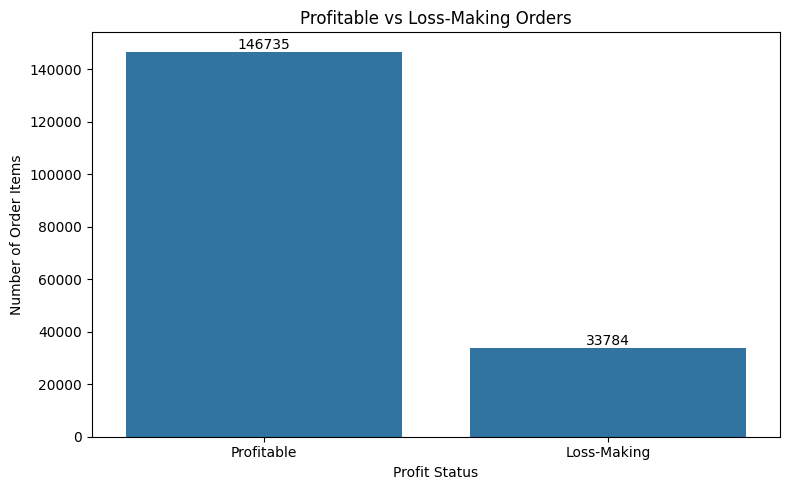

In [106]:
profit_status_counts = df["Profit_Status"].value_counts()

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=profit_status_counts.index,
    y=profit_status_counts.values
)

plt.title("Profitable vs Loss-Making Orders")
plt.xlabel("Profit Status")
plt.ylabel("Number of Order Items")

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

## Visualization 2 — Discounting and Profitability

The relationship between discount status and profitability is visualized to compare profit margins for discounted and non-discounted order items.

This provides a direct visual comparison of the profitability associated with applying discounts.

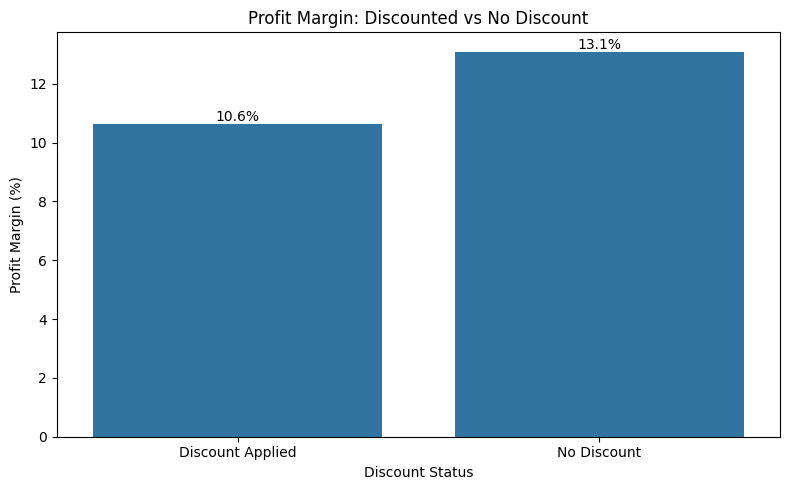

In [107]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=discount_comparison,
    x="Discount_Status",
    y="Profit_Margin_%"
)

plt.title("Profit Margin: Discounted vs No Discount")
plt.xlabel("Discount Status")
plt.ylabel("Profit Margin (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

## Visualization 3 — Loss Rate by Discount Band

The loss rate is visualized across discount bands to examine whether higher discount levels are associated with a greater proportion of loss-making order items.


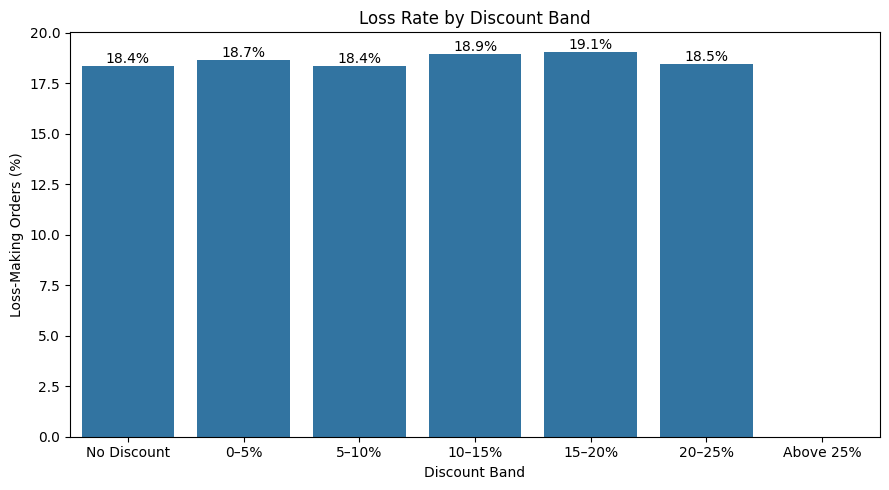

In [108]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=discount_analysis,
    x="Discount_Band",
    y="Loss_Rate_%"
)

plt.title("Loss Rate by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Loss-Making Orders (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

## Visualization 4 — Profit Margin by Discount Band

This visualization compares profit margins across discount bands to examine how different discount levels are associated with overall profitability.


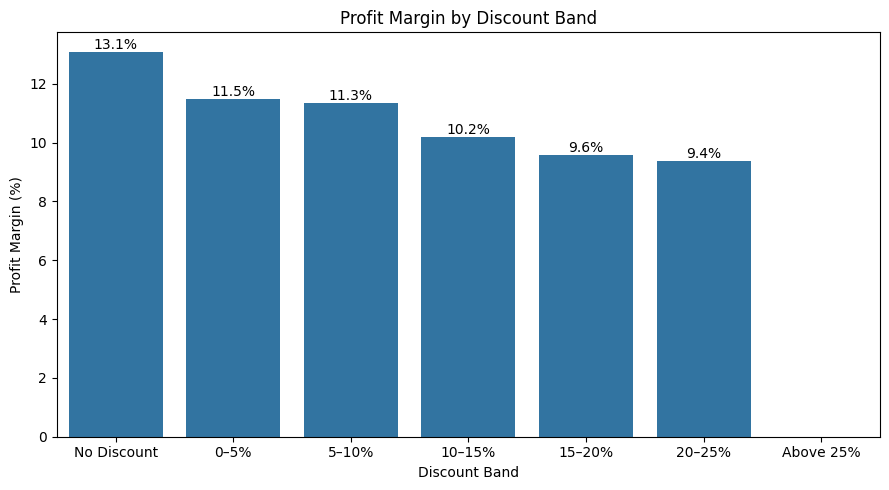

In [125]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=discount_analysis,
    x="Discount_Band",
    y="Profit_Margin_%"
)

plt.title("Profit Margin by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Profit Margin (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.savefig(
    "../outputs/figures/discount_vs_margin.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Visualization 5 — Total Profit by Customer Segment

This visualization compares total profit across customer segments to identify which segments contribute most to overall profitability.


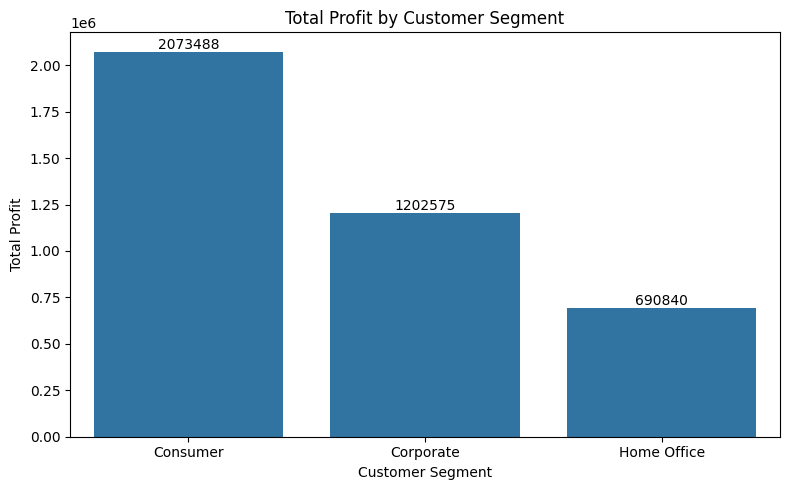

In [110]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=segment_analysis,
    x="Customer Segment",
    y="Total_Profit"
)

plt.title("Total Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Profit")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

## Visualization 6 — Top 15 Product Categories by Total Profit

This visualization compares the 15 highest-profit product categories to identify the categories contributing most to overall profitability.


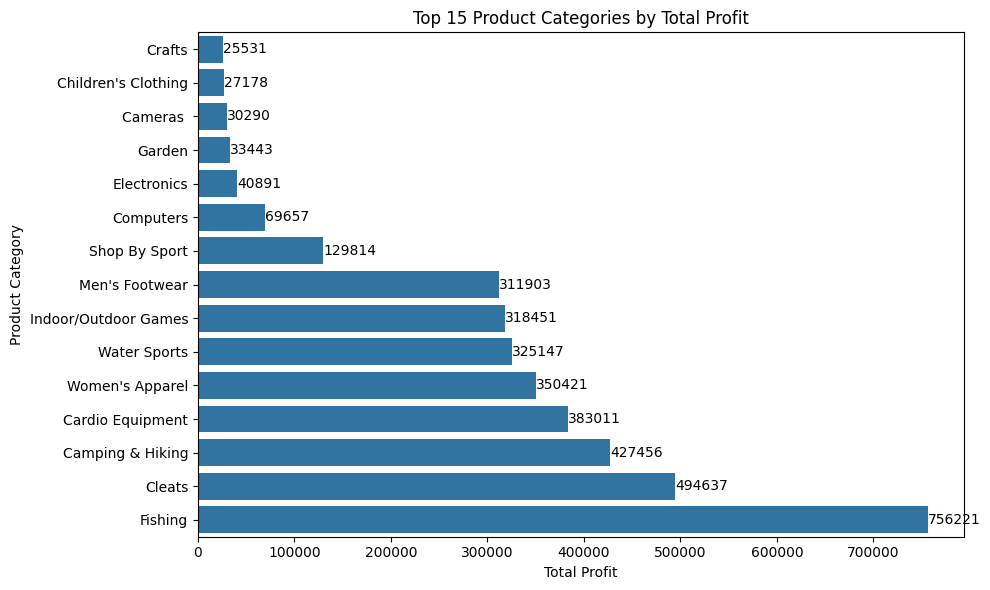

In [126]:
plt.figure(figsize=(10, 6))

top_categories = (
    category_analysis
    .sort_values("Total_Profit", ascending=False)
    .head(15)
    .sort_values("Total_Profit")
)

ax = sns.barplot(
    data=top_categories,
    x="Total_Profit",
    y="Category Name"
)

plt.title("Top 15 Product Categories by Total Profit")
plt.xlabel("Total Profit")
plt.ylabel("Product Category")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/category_profitability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Visualization 7 — Top 15 Product Categories by Loss Rate

This visualization compares loss-making order rates across product categories with at least 100 orders, highlighting categories with relatively higher exposure to unprofitable orders.


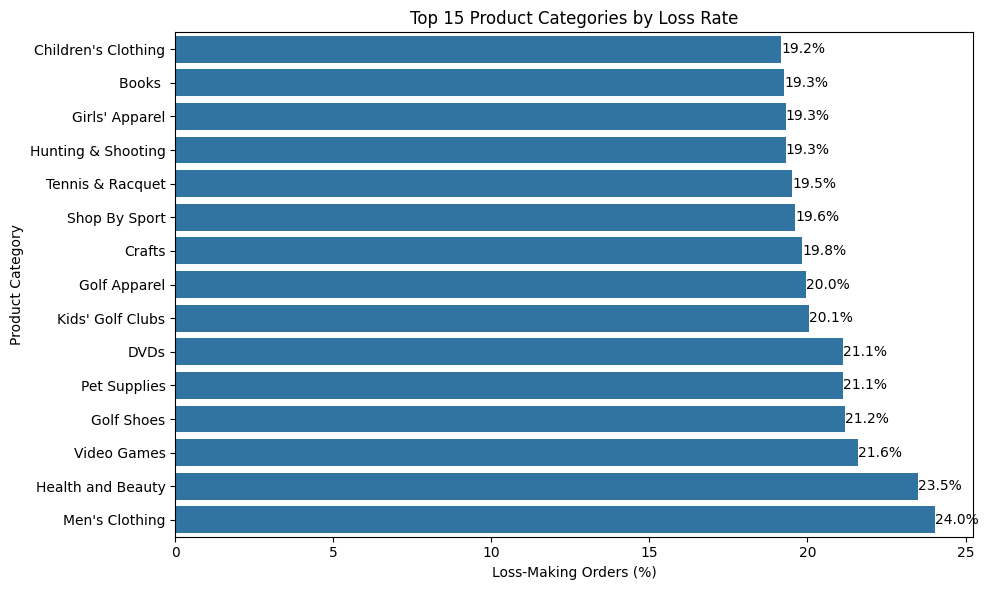

In [112]:
plt.figure(figsize=(10, 6))

top_loss_categories = (
    category_loss_rate
    .sort_values("Loss_Rate_%", ascending=False)
    .head(15)
    .sort_values("Loss_Rate_%")
)

ax = sns.barplot(
    data=top_loss_categories,
    x="Loss_Rate_%",
    y="Category Name"
)

plt.title("Top 15 Product Categories by Loss Rate")
plt.xlabel("Loss-Making Orders (%)")
plt.ylabel("Product Category")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

## Visualization 8 — Loss Rate by Shipping Performance

This visualization compares the loss-making order rate across Early, On Time, and Late shipments to assess whether shipping performance is associated with profitability.


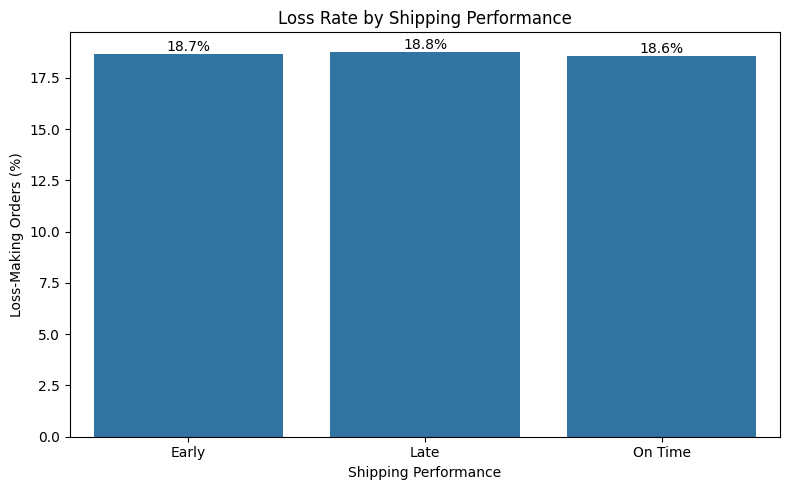

In [113]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=shipping_performance_analysis,
    x="Shipping_Performance",
    y="Loss_Rate_%"
)

plt.title("Loss Rate by Shipping Performance")
plt.xlabel("Shipping Performance")
plt.ylabel("Loss-Making Orders (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

## Visualization 9 — Total Profit by Region

This visualization compares total profit across regions to identify the regions contributing most to overall profitability.


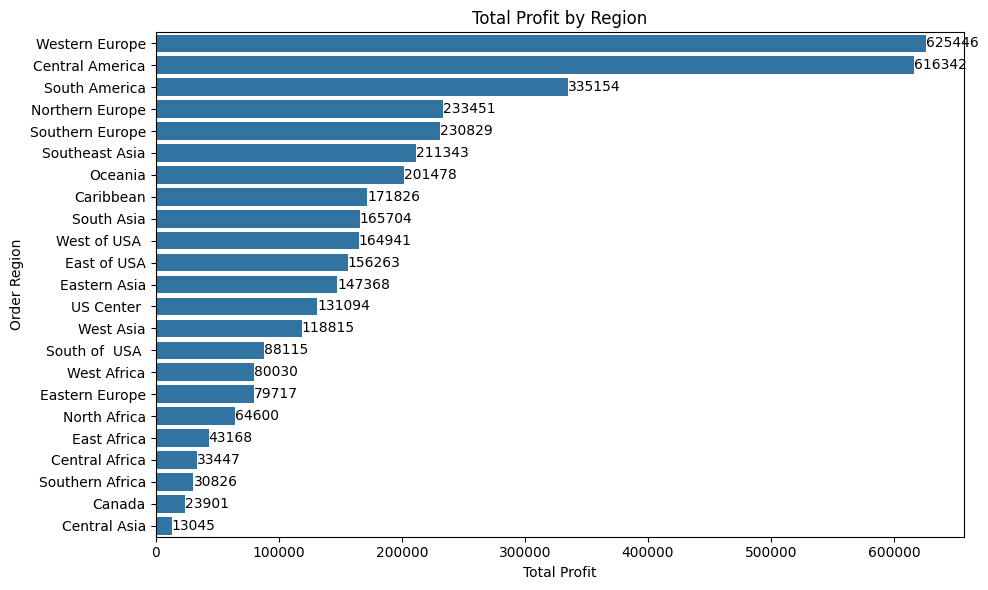

In [114]:
plt.figure(figsize=(10, 6))

region_profit = (
    region_analysis
    .sort_values("Total_Profit", ascending=False)
)

ax = sns.barplot(
    data=region_profit,
    x="Total_Profit",
    y="Order Region"
)

plt.title("Total Profit by Region")
plt.xlabel("Total Profit")
plt.ylabel("Order Region")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

## Visualization 10 — Profit Margin by Region

This visualization compares profit margins across regions to identify regions that generate stronger profitability relative to their sales volume.


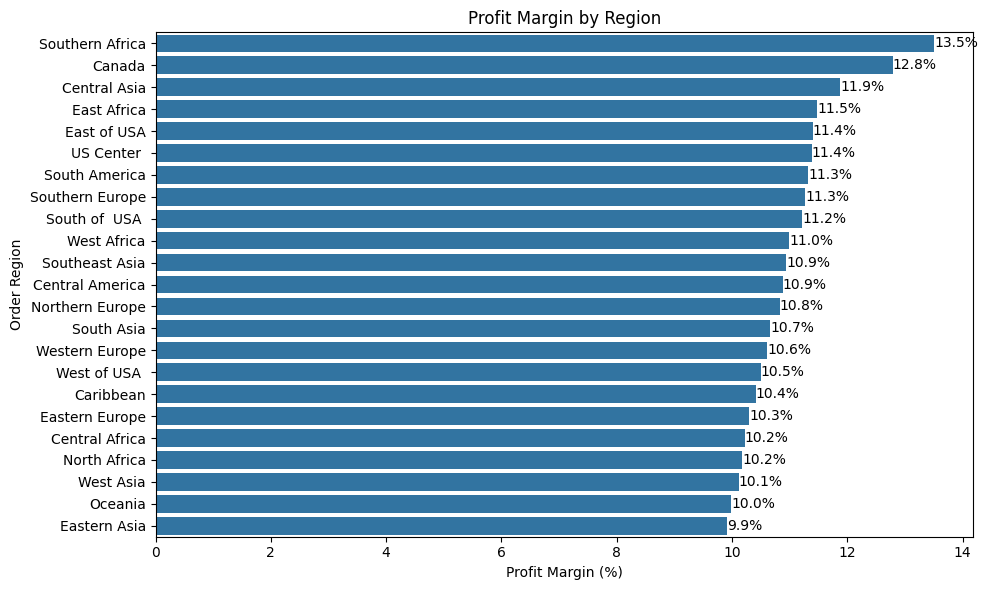

In [115]:
plt.figure(figsize=(10, 6))

region_margin = (
    region_analysis
    .sort_values("Profit_Margin_%", ascending=False)
)

ax = sns.barplot(
    data=region_margin,
    x="Profit_Margin_%",
    y="Order Region"
)

plt.title("Profit Margin by Region")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Order Region")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

## Visualization 11 — Average Profit by Discount Band

This visualization compares average order profit across discount bands to examine how different discount levels are associated with order-level profitability.


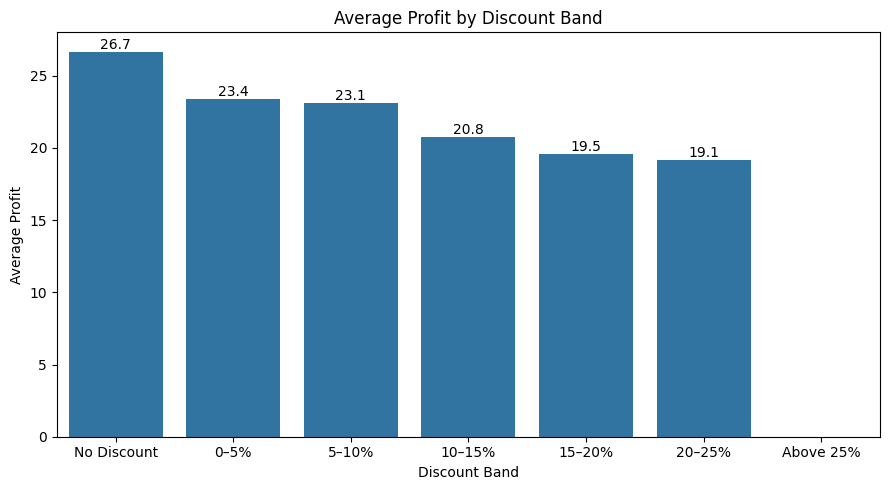

In [116]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=discount_analysis,
    x="Discount_Band",
    y="Avg_Profit"
)

plt.title("Average Profit by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Average Profit")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.tight_layout()
plt.show()

## Visualization 12 — Loss Rate by Customer Segment

This visualization compares the proportion of loss-making orders across customer segments to identify segments with relatively higher exposure to unprofitable orders.


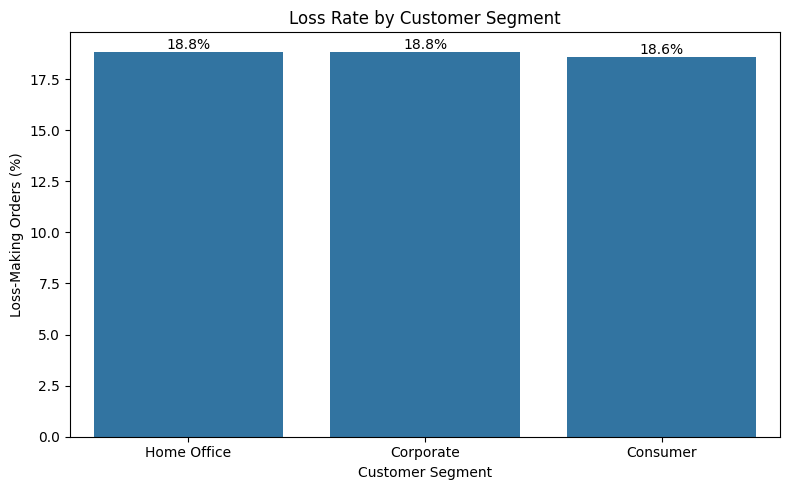

In [117]:
plt.figure(figsize=(8, 5))

segment_loss = segment_analysis.sort_values(
    "Loss_Rate_%",
    ascending=False
)

ax = sns.barplot(
    data=segment_loss,
    x="Customer Segment",
    y="Loss_Rate_%"
)

plt.title("Loss Rate by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Loss-Making Orders (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

## Visualization 13 — Average Profit by Shipping Mode

This visualization compares the average profit per order across different shipping modes to identify differences in financial performance associated with shipping choices.


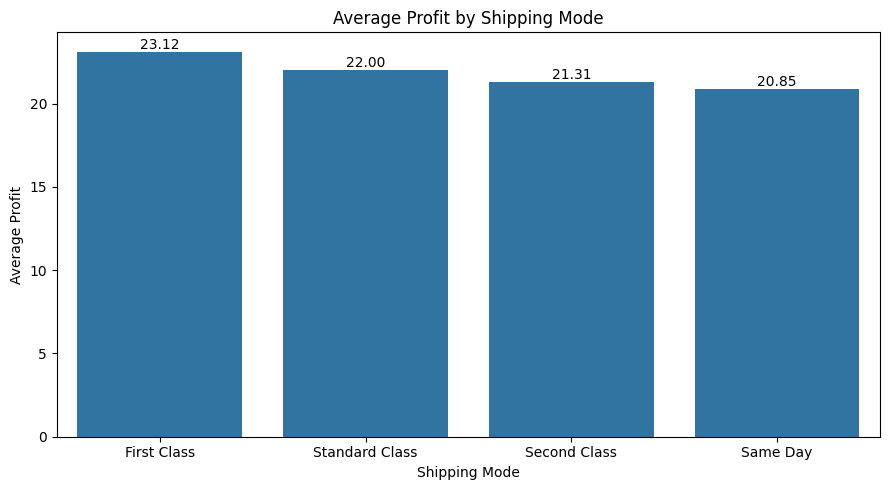

In [118]:
plt.figure(figsize=(9, 5))

shipping_profit = shipping_mode_analysis.sort_values(
    "Avg_Profit",
    ascending=False
)

ax = sns.barplot(
    data=shipping_profit,
    x="Shipping Mode",
    y="Avg_Profit"
)

plt.title("Average Profit by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Average Profit")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()

## Visualization 14 — Top 10 Customers by Total Profit

This visualization compares the top 10 customers by total profit to identify the customers contributing most strongly to overall profitability.


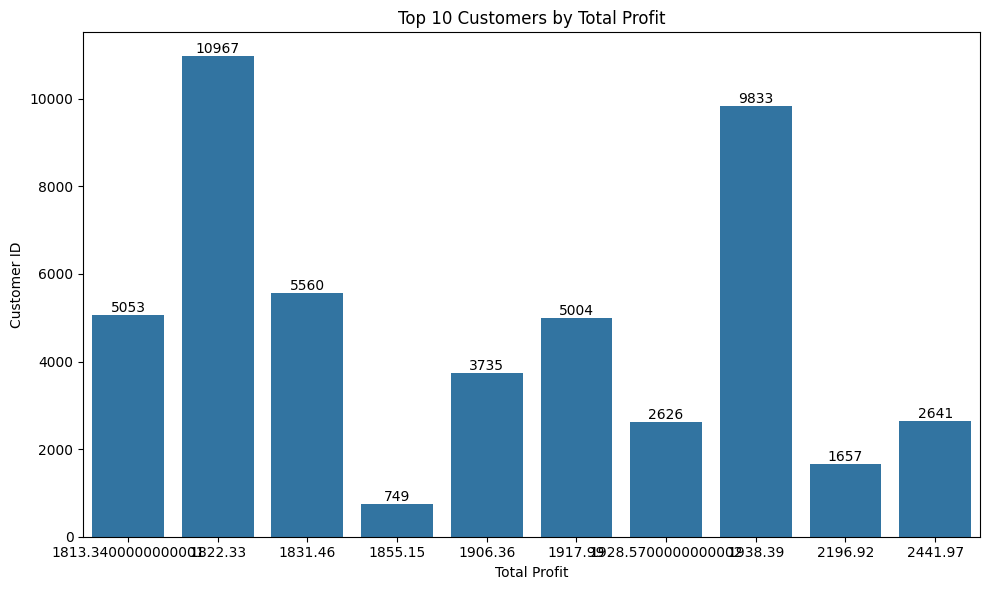

In [119]:
plt.figure(figsize=(10, 6))

top_customer_profit = (
    customer_analysis
    .sort_values("Total_Profit", ascending=False)
    .head(10)
    .sort_values("Total_Profit")
)

ax = sns.barplot(
    data=top_customer_profit,
    x="Total_Profit",
    y="Customer Id"
)

plt.title("Top 10 Customers by Total Profit")
plt.xlabel("Total Profit")
plt.ylabel("Customer ID")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

## Visualization 15 — Top 10 Customers by Total Sales

This visualization compares the top 10 customers by total sales to identify the customers generating the greatest revenue contribution and provide context for their profitability performance.


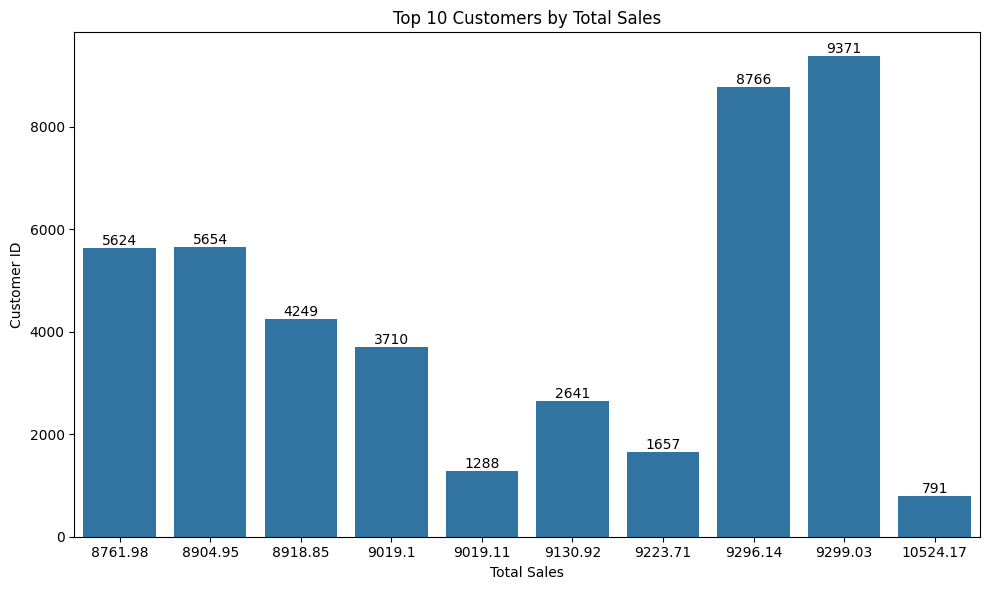

In [120]:
plt.figure(figsize=(10, 6))

top_customer_sales = (
    customer_analysis
    .sort_values("Total_Sales", ascending=False)
    .head(10)
    .sort_values("Total_Sales")
)

ax = sns.barplot(
    data=top_customer_sales,
    x="Total_Sales",
    y="Customer Id"
)

plt.title("Top 10 Customers by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Customer ID")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

## Visualization 16 — Average Profit by Order Quantity

This visualization compares average profit across different order quantities to examine whether order size is associated with differences in order-level profitability.


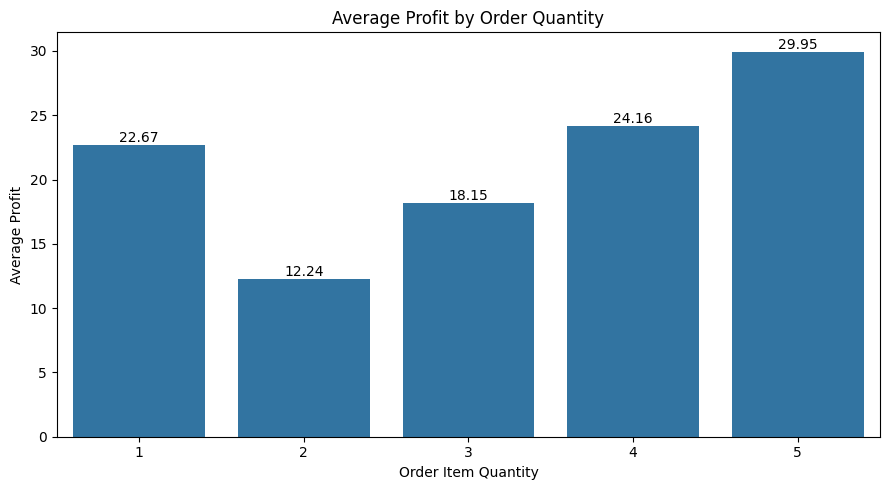

In [121]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=quantity_analysis,
    x="Order Item Quantity",
    y="Avg_Profit"
)

plt.title("Average Profit by Order Quantity")
plt.xlabel("Order Item Quantity")
plt.ylabel("Average Profit")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()

## Visualization 17 — Loss Rate by Order Quantity

This visualization compares the proportion of loss-making orders across different order quantities to identify order sizes with relatively higher exposure to unprofitable orders.


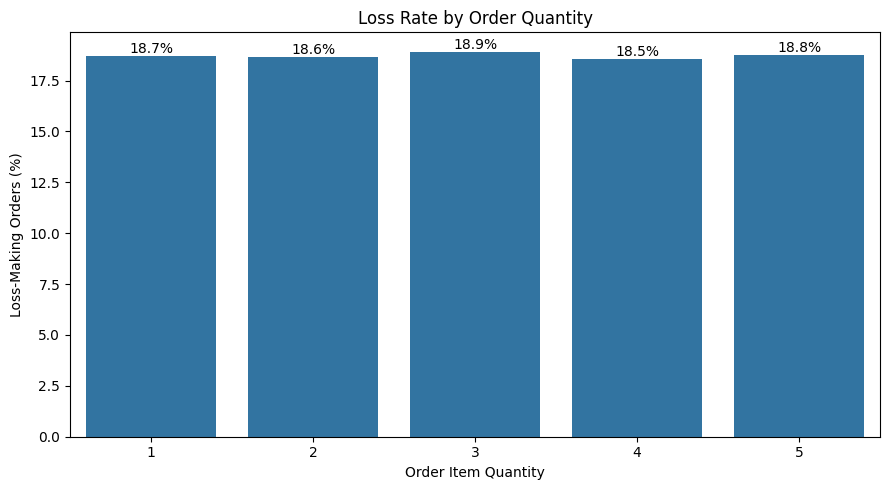

In [122]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=quantity_analysis,
    x="Order Item Quantity",
    y="Loss_Rate_%"
)

plt.title("Loss Rate by Order Quantity")
plt.xlabel("Order Item Quantity")
plt.ylabel("Loss-Making Orders (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

## Visualization 18 — High-Discount Categories: Profit Margin

This visualization compares profit margins across product categories for orders receiving a 20–25% discount, highlighting categories where high discounting is associated with relatively weaker profitability.


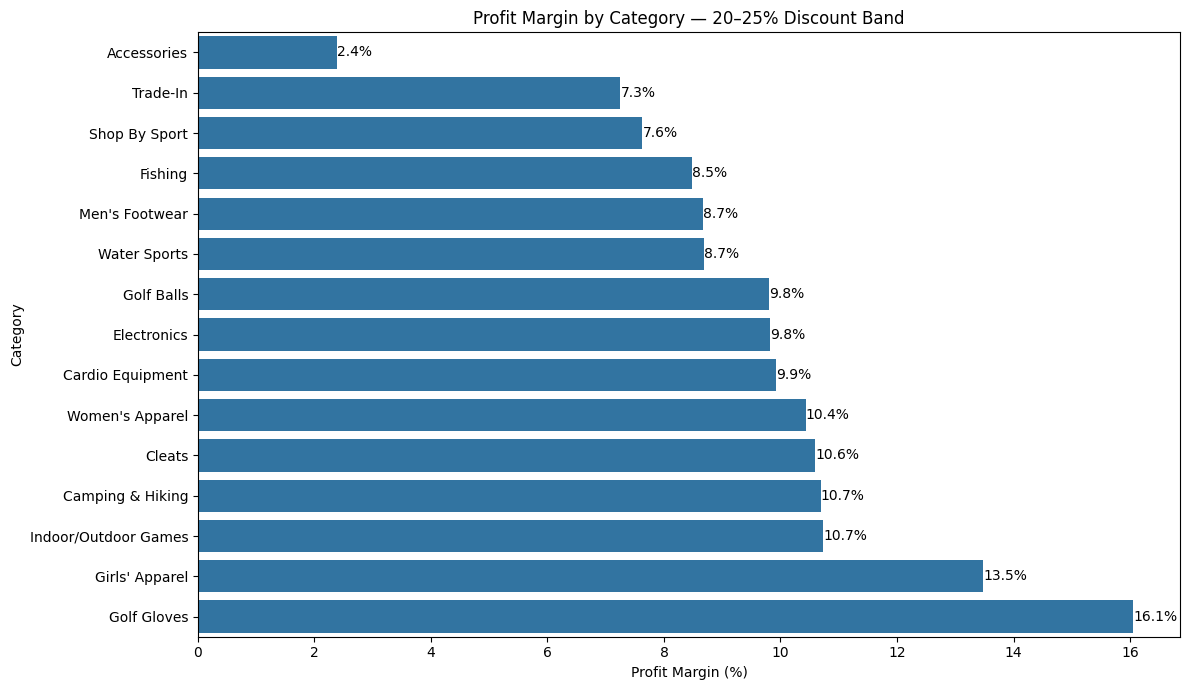

In [123]:
plt.figure(figsize=(12, 7))

high_discount_plot = (
    high_discount_analysis
    .sort_values("Profit_Margin_%", ascending=True)
)

ax = sns.barplot(
    data=high_discount_plot,
    x="Profit_Margin_%",
    y="Category Name"
)

plt.title("Profit Margin by Category — 20–25% Discount Band")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Category")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

## Visualization 19 — High-Revenue, Low-Margin Products

This visualization highlights products that combine relatively high revenue contribution with profit margins below the overall business profit margin.

These products are commercially important because they generate substantial sales but comparatively weaker margins. They represent potential areas for further review of pricing, discounting, product mix, or cost structure.

The visualization is intended to prioritize products for investigation and does not establish the specific cause of their lower margins.

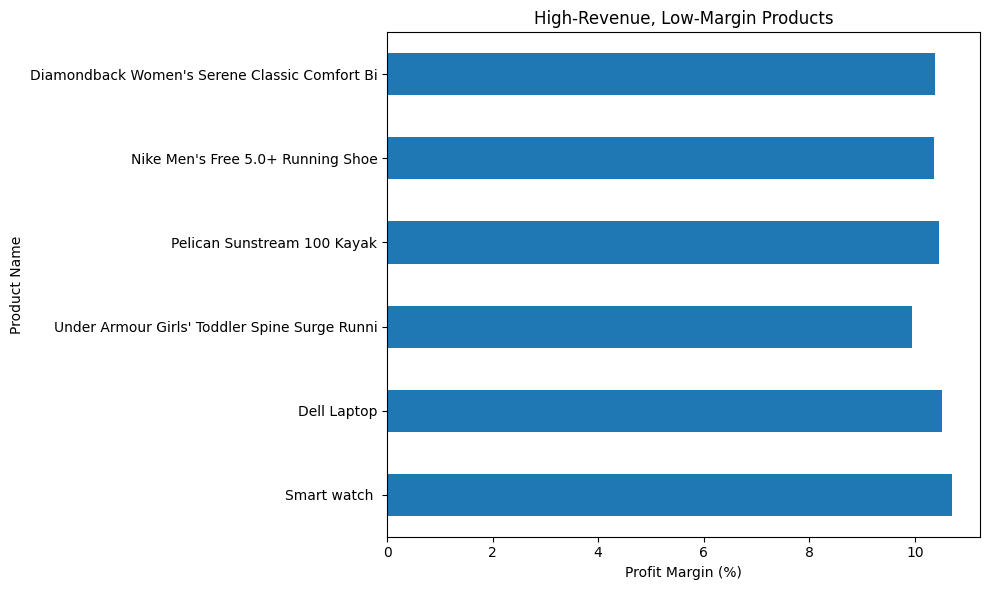

In [127]:
high_revenue_low_margin[
    ["Product Name", "Total_Sales", "Profit_Margin_%"]
].sort_values(
    "Total_Sales",
    ascending=True
).plot(
    kind="barh",
    x="Product Name",
    y="Profit_Margin_%",
    figsize=(10, 6),
    legend=False
)

plt.title("High-Revenue, Low-Margin Products")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Product Name")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/high_revenue_low_margin_products.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Visualization Insights

The visual analysis provides a consolidated view of the factors associated with profitability, loss-making orders, discounting, customer performance, product categories, and logistics operations.

### Key Findings

- The overall profitability analysis shows that while most order items are profitable, a meaningful proportion of orders are loss-making, indicating a clear opportunity for margin improvement.

- Discounting shows a noticeable relationship with profitability. Profit margins decline consistently as discount levels increase, indicating margin compression at higher discount levels. However, loss rates fluctuate within a relatively narrow range and do not increase monotonically with discount level. This suggests that higher discounts are more clearly associated with margin compression than with a consistent increase in loss frequency.

- The customer segment analysis shows differences in total profit and loss rates across segments. This indicates that customer segments should be evaluated not only by revenue contribution but also by profitability quality.

- Product-category analysis highlights substantial variation in both total profit and loss rates. High-volume categories can contribute strongly to total profit while still having relatively high exposure to loss-making orders.

- Regional analysis demonstrates that profitability varies across regions. Regions with high total profit are not necessarily the regions with the strongest profit margins, making both scale and efficiency important when evaluating regional performance.

- Customer-level analysis shows that the customers generating the highest sales are not necessarily the same customers generating the highest total profit. This highlights the importance of evaluating customer profitability rather than relying on revenue alone.

- Order quantity analysis indicates differences in average profit and loss rates across order quantities. These patterns can help identify order-size levels that may require further operational or pricing investigation.

- Shipping performance shows only relatively small differences in loss rates between Early, On Time, and Late shipments. Therefore, shipping delay does not appear to be a major driver of order-level profitability in this dataset.

- Shipping-mode analysis shows differences in average profitability across shipping choices. However, these differences represent associations within the dataset and should not be interpreted as evidence that shipping mode directly causes changes in profitability.

- The high-discount category analysis identifies categories where 20–25% discounting is associated with comparatively weaker profit margins. These categories may warrant closer review of pricing strategy, discount policies, and product-level costs.

### Overall Visualization Conclusion

Overall, the visual analysis suggests that profitability is influenced by a combination of pricing and discounting, product and customer mix, regional performance, and operational characteristics. Among these factors, discounting, product-category performance, and customer profitability provide particularly important areas for further investigation.

The visualizations describe relationships and patterns present in the dataset; they do not establish causal relationships. The findings should therefore be used to identify business areas requiring deeper investigation and potential corrective action.

# Business Recommendations

Based on the profitability, discounting, customer, product, regional, and logistics analysis, the following actions could help improve profitability and reduce exposure to loss-making orders:

1. **Review high-discount strategies**  
   Discounting should be monitored carefully, particularly within the 20–25% discount band. Categories showing weaker profit margins at high discount levels should be reviewed for pricing, cost structure, and discount-policy adjustments.

2. **Introduce category-level discount controls**  
   Discount policies should not necessarily be applied uniformly across all product categories. Categories with relatively high loss rates or weak margins under high discounts may require tighter discount limits.

3. **Monitor loss-making customer accounts**  
   Customer profitability should be evaluated alongside sales volume. High-revenue customers should not be considered automatically valuable if their profitability is comparatively weak.

4. **Investigate high-loss product categories**  
   Categories with consistently high loss rates should be investigated further to identify potential issues related to pricing, discounts, product costs, or product mix.

5. **Use both profit and margin when evaluating regions**  
   Regional decisions should consider both total profit and profit margin. High-volume regions may generate substantial absolute profit while smaller regions may demonstrate stronger profitability relative to sales.

6. **Monitor order-size profitability**  
   Differences in profitability and loss rates across order quantities should be monitored to identify order sizes that may require further operational or pricing investigation.

7. **Continue monitoring shipping performance**  
   Shipping performance should be monitored as an operational metric, but the relatively small differences in loss rates across shipping-performance groups suggest that shipping delays should not currently be treated as a primary profitability driver.

8. **Use profitability-based decision making**  
   Business decisions should consider multiple measures—including total profit, profit margin, average profit, and loss rate—rather than relying on sales or order volume alone.

These recommendations are based on associations and patterns observed in the dataset. Further investigation using cost, pricing, customer-level, and operational data would be required before implementing major business-policy changes.

# Final Project Conclusion

This project provided a comprehensive analysis of order-level sales, profitability, discounting, customer behavior, product categories, regional performance, and logistics operations using the APL Logistics dataset.

The initial data-quality assessment found no missing values or duplicate records. Financial validation also confirmed that `Order Item Total` is consistent with `Sales − Order Item Discount` within a 0.01 rounding tolerance. The comparison of `Benefit per order` with `Order Profit Per Order` further showed that the two measures are identical, making the former redundant for analytical purposes.

The profitability analysis showed that the dataset contains both profitable and loss-making order items, with meaningful variation across customers, product categories, customer segments, regions, discount levels, order quantities, and shipping-related factors.

Discounting emerged as an important area for investigation. Higher discount levels were consistently associated with weaker profit margins, indicating margin compression as discount levels increased. However, loss rates fluctuated across discount bands rather than increasing consistently. The category-level high-discount analysis further highlighted categories where substantial discounting was associated with relatively weaker profit margins. This suggests that discount strategies should be evaluated together with product-level profitability and costs rather than being applied uniformly.

Customer and product analysis demonstrated that revenue contribution does not necessarily correspond directly to profitability. Similarly, regional analysis showed that total profit and profit margin provide different perspectives on performance. Therefore, business performance should be evaluated using multiple measures rather than relying on sales volume or total profit alone.

Profit concentration analysis also revealed a strong difference between products and customers. The top 10 products account for approximately 89.70% of total profit, while the top 10 customers account for only approximately 0.50%. This indicates that profitability is highly concentrated at the product level but more widely distributed across customers, highlighting the need for different strategies for product portfolio management and customer profitability management.

The logistics analysis showed differences across shipping modes and shipping-performance groups. However, the relatively small differences in loss rates between Early, On Time, and Late shipments suggest that shipping delays are not a major driver of order-level profitability within this dataset. These operational variables should therefore be monitored, while greater attention can be directed toward factors showing stronger profitability associations.

Overall, the analysis indicates that profitability improvement should focus particularly on effective discount management, category-level profitability, customer profitability, and the identification of areas with high loss exposure. The findings provide a data-driven basis for further investigation and potential improvements in pricing, discount policies, customer management, and operational decision-making.

The conclusions of this project describe patterns and associations observed in the available data and should not be interpreted as evidence of direct causation. Additional information such as detailed product costs, customer acquisition costs, pricing policies, and operational expenses would be required for deeper causal analysis and more precise business decision-making.